# CCLE TP53 Modeling Notebook: mRNA-first with metadata fine-tuning

This notebook is the modeling companion to the revised EDA notebook.

The structure now directly follows the professor's guidance:

1. **mRNA-only models** — primary scientific result
2. **metadata-only models** — secondary benchmark
3. **mRNA + metadata models** — fine-tuned practical model

So the notebook is no longer trying to answer only “which model family wins?”
It is now answering a clearer project question:

> How much predictive signal comes from mRNA alone, how much from metadata alone, and does metadata improve the mRNA model?


## Notebook outputs

The notebook produces:
- validation and test comparisons for the three model tiers
- a fixed **primary mRNA model** (`rna_enet_logreg`)
- a best metadata-only model
- a best mRNA + metadata model
- coefficient-based interpretation of the primary mRNA model
- robustness checks for the mRNA-first claim


## 0. Setup


In [1]:
from pathlib import Path
import shutil

SEARCH_ROOTS = [
    Path("/kaggle/input"),
    Path("/content"),
    Path("/mnt/data"),
    Path("tp53_completed_notebooks"),
]

REQUIRED_CCLE_FILES = [
    "ccle_sample_metadata.parquet",
    "ccle_split_membership.parquet",
    "ccle_X_rna_filtered_all.parquet",
    "ccle_X_meta.parquet",
    "ccle_modeling_schema.json",
]

OPTIONAL_CCLE_FILES = [
    "ccle_sure_outliers.txt",
    "ccle_possible_outliers.txt",
]

def find_processed_dir(required_files, search_roots):
    candidates = []

    for root in search_roots:
        if not root.exists():
            continue

        for p in root.rglob("processed"):
            if not p.is_dir():
                continue

            if all((p / f).exists() for f in required_files):
                candidates.append(p)

    if not candidates:
        raise FileNotFoundError(
            "Could not find a processed/ directory containing all required CCLE files.\n"
            f"Required files: {required_files}\n"
            f"Searched roots: {[str(r) for r in search_roots]}"
        )

    candidates = sorted(
        candidates,
        key=lambda x: (
            0 if str(x).startswith("/kaggle/input") else 1,
            len(str(x)),
        ),
    )

    return candidates[0]


SRC_PROCESSED = find_processed_dir(REQUIRED_CCLE_FILES, SEARCH_ROOTS)
DST_PROCESSED = Path("../processed")

print(f"Found CCLE processed directory: {SRC_PROCESSED}")

# Always replace local processed/ with the detected CCLE processed folder.
# This avoids accidentally using stale TCGA files or an empty processed directory.
if DST_PROCESSED.exists():
    shutil.rmtree(DST_PROCESSED)

shutil.copytree(SRC_PROCESSED, DST_PROCESSED)

print(f"Copied CCLE processed files to writable directory: {DST_PROCESSED.resolve()}")

print("\nRequired files:")
for f in REQUIRED_CCLE_FILES:
    print("FOUND" if (DST_PROCESSED / f).exists() else "MISSING", f)

print("\nOptional files:")
for f in OPTIONAL_CCLE_FILES:
    print("FOUND" if (DST_PROCESSED / f).exists() else "MISSING", f)

PROCESSED_DIR = DST_PROCESSED

Found CCLE processed directory: /kaggle/input/datasets/cameroncaputa/ccle-tp53/processed
Copied CCLE processed files to writable directory: /kaggle/working/processed

Required files:
FOUND ccle_sample_metadata.parquet
FOUND ccle_split_membership.parquet
FOUND ccle_X_rna_filtered_all.parquet
FOUND ccle_X_meta.parquet
FOUND ccle_modeling_schema.json

Optional files:
FOUND ccle_sure_outliers.txt
FOUND ccle_possible_outliers.txt


In [2]:
from pathlib import Path
from IPython.display import display
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.multitest import multipletests

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

RNG = 42
PROC = Path("../processed")
PROC.mkdir(exist_ok=True, parents=True)

CONFIG = {
    "primary_model_name": "rna_enet_logreg",
    "primary_label_fallback": "TP53_mut_nonsyn",
    "corr_alpha": 0.05,
    "corr_min_abs_r": 0.15,
    "max_corr_features": 300,
    "selector_fallback_top_n": 200,
    "min_meta_category_n": 15,
    "cv_splits": 5,
    "cv_scoring": "average_precision",
    "bootstrap_reps": 1000,
    "grouped_outer_splits": 5,
    "grouped_inner_splits": 3,
    "label_sensitivity_labels": ["TP53_mut_nonsyn", "TP53_mut_lof"],
    "top_k_interpretation": 30,
    "evaluate_optional_rf": False,
}

TP53_TARGETS = {
    "APAF1", "ATF3", "BAK1", "BAX", "BBC3", "BID", "BTG2", "CASP6", "CCNG1", "CCNG2",
    "CDKN1A", "DDB2", "DRAM1", "EDA2R", "FAS", "FDXR", "FOXO3", "GADD45A", "GADD45B",
    "GDF15", "IGFBP3", "LIF", "LRDD", "MDM2", "MDM4", "NDRG1", "PERP", "PIDD1", "PLK2",
    "PLK3", "PMAIP1", "POLH", "PTEN", "RPS27L", "RRM2B", "RRAD", "SERPINE1", "SESN1",
    "SESN2", "SESN3", "SFN", "SIAH1", "THBS1", "TIGAR", "TNFRSF10B", "TP53AIP1",
    "TP53I3", "TP53INP1", "WIG1", "XPC", "ZMAT3",
}
TARGET_ALIASES = {"WIG1": "ZMAT3"}
LINEAGE_MARKER_HINTS = {"EPCAM", "CLDN7", "KRT8", "KRT18", "KRT19", "MUC1"}

print(json.dumps(CONFIG, indent=2))


{
  "primary_model_name": "rna_enet_logreg",
  "primary_label_fallback": "TP53_mut_nonsyn",
  "corr_alpha": 0.05,
  "corr_min_abs_r": 0.15,
  "max_corr_features": 300,
  "selector_fallback_top_n": 200,
  "min_meta_category_n": 15,
  "cv_splits": 5,
  "cv_scoring": "average_precision",
  "bootstrap_reps": 1000,
  "grouped_outer_splits": 5,
  "grouped_inner_splits": 3,
  "label_sensitivity_labels": [
    "TP53_mut_nonsyn",
    "TP53_mut_lof"
  ],
  "top_k_interpretation": 30,
  "evaluate_optional_rf": false
}


### Helper functions


In [3]:
def load_parquet_with_id(path, id_col="ModelID"):
    df = pd.read_parquet(path)
    if id_col not in df.columns:
        raise ValueError(f"{path} is missing required ID column {id_col}")
    df[id_col] = df[id_col].astype(str)
    return df.set_index(id_col)


def save_parquet_with_id(df, filename, id_col="ModelID"):
    out = df.copy()
    out.insert(0, id_col, out.index.astype(str))
    out.to_parquet(PROC / filename, index=False)


def save_series_with_id(s, filename, value_name=None, id_col="ModelID"):
    s = s.copy()
    if value_name is not None:
        s.name = value_name
    s.rename_axis(id_col).reset_index().to_parquet(PROC / filename, index=False)


def make_dense_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def corr_against_binary(X, y, method="pearson"):
    if not isinstance(X, pd.DataFrame):
        raise TypeError("corr_against_binary expects a pandas DataFrame")
    y = pd.Series(y, index=X.index).astype(float)
    assert X.index.equals(y.index), "X and y must have aligned indices."

    y_vec = y.to_numpy()
    cols = X.columns

    if method == "spearman":
        X_use = X.rank(axis=0, method="average").to_numpy(dtype=float)
        y_use = pd.Series(y_vec, index=y.index).rank(method="average").to_numpy(dtype=float)
    else:
        X_use = X.to_numpy(dtype=float)
        y_use = y_vec.astype(float)

    x_std = X_use.std(axis=0, ddof=1)
    valid = x_std > 0
    valid_cols = cols[valid]

    out = pd.DataFrame(index=cols)
    out[f"{method}_r"] = np.nan
    out[f"{method}_p"] = np.nan
    out[f"{method}_p_bh"] = np.nan

    if valid.sum() == 0:
        return out

    Xv = X_use[:, valid]
    yc = y_use - y_use.mean()
    Xc = Xv - Xv.mean(axis=0, keepdims=True)

    denom = np.sqrt((Xc ** 2).sum(axis=0) * (yc ** 2).sum())
    r = (Xc * yc[:, None]).sum(axis=0) / np.clip(denom, 1e-12, None)

    n = len(y_use)
    t_stat = r * np.sqrt((n - 2) / np.clip(1 - r ** 2, 1e-12, None))
    p = 2 * stats.t.sf(np.abs(t_stat), df=n - 2)
    p_bh = multipletests(p, method="fdr_bh")[1]

    out.loc[valid_cols, f"{method}_r"] = r
    out.loc[valid_cols, f"{method}_p"] = p
    out.loc[valid_cols, f"{method}_p_bh"] = p_bh
    return out


def get_prob(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        score = estimator.decision_function(X)
        return 1 / (1 + np.exp(-score))
    raise AttributeError("Estimator has neither predict_proba nor decision_function")


def choose_threshold(y_true, prob):
    thresholds = np.unique(np.round(prob, 6))
    if len(thresholds) == 0:
        return 0.5
    thresholds = np.concatenate([[0.0], thresholds, [1.0]])
    best_thr, best_score = 0.5, -np.inf
    for thr in thresholds:
        pred = (prob >= thr).astype(int)
        score = balanced_accuracy_score(y_true, pred)
        if score > best_score:
            best_thr, best_score = thr, score
    return float(best_thr)


def evaluate_binary_metrics(y_true, prob, threshold=0.5):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "auroc": roc_auc_score(y_true, prob),
        "auprc": average_precision_score(y_true, prob),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "f1": f1_score(y_true, pred, zero_division=0),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "specificity": tn / max(tn + fp, 1),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "threshold": float(threshold),
    }


def bootstrap_metric_ci(y_true, prob, metric_fn, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    prob = np.asarray(prob)
    vals = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yb = y_true[idx]
        if len(np.unique(yb)) < 2:
            continue
        vals.append(metric_fn(yb, prob[idx]))
    if len(vals) == 0:
        return (np.nan, np.nan, np.nan)
    vals = np.asarray(vals, dtype=float)
    return float(np.mean(vals)), float(np.quantile(vals, 0.025)), float(np.quantile(vals, 0.975))


### Custom transformers and feature builders


In [4]:
class CorrTargetGeneSelector(BaseEstimator, TransformerMixin):
    """Fold-safe supervised selector for mRNA features."""

    def __init__(
        self,
        corr_alpha=0.05,
        corr_min_abs_r=0.15,
        max_corr_features=300,
        fallback_top_n=200,
        tp53_targets=None,
        target_aliases=None,
    ):
        self.corr_alpha = corr_alpha
        self.corr_min_abs_r = corr_min_abs_r
        self.max_corr_features = max_corr_features
        self.fallback_top_n = fallback_top_n
        self.tp53_targets = tp53_targets
        self.target_aliases = target_aliases

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("CorrTargetGeneSelector expects a pandas DataFrame")

        tp53_targets = set() if self.tp53_targets is None else set(self.tp53_targets)
        target_aliases = {} if self.target_aliases is None else dict(self.target_aliases)

        y = pd.Series(y, index=X.index).astype(int)
        pear = corr_against_binary(X, y, method="pearson")
        spear = corr_against_binary(X, y, method="spearman")
        corr = pear.join(spear)
        corr["abs_pearson_r"] = corr["pearson_r"].abs()
        corr["abs_spearman_r"] = corr["spearman_r"].abs()

        strict_ranked = corr.loc[
            (corr["pearson_p_bh"] <= self.corr_alpha)
            & (corr["spearman_p_bh"] <= self.corr_alpha)
            & (corr["abs_pearson_r"] >= self.corr_min_abs_r)
        ].sort_values("abs_pearson_r", ascending=False)

        if len(strict_ranked) == 0:
            strict_ranked = corr.sort_values("abs_pearson_r", ascending=False).head(self.fallback_top_n)

        corr_genes = set(strict_ranked.head(self.max_corr_features).index)

        targets_present = set()
        for gene in sorted(tp53_targets):
            if gene in X.columns:
                targets_present.add(gene)
            elif gene in target_aliases and target_aliases[gene] in X.columns:
                targets_present.add(target_aliases[gene])

        selected = sorted(corr_genes | targets_present)
        if len(selected) == 0:
            raise ValueError("Selector produced zero genes; inspect the fold or relax thresholds.")

        self.selected_genes_ = selected
        self.corr_table_ = corr.sort_values("abs_pearson_r", ascending=False)
        self.selection_manifest_ = pd.DataFrame(index=selected)
        self.selection_manifest_["from_correlation"] = self.selection_manifest_.index.isin(corr_genes)
        self.selection_manifest_["from_tp53_target_list"] = self.selection_manifest_.index.isin(targets_present)
        self.selection_manifest_["pearson_r"] = corr.reindex(self.selection_manifest_.index)["pearson_r"]
        self.selection_manifest_["abs_pearson_r"] = self.selection_manifest_["pearson_r"].abs()
        self.selection_manifest_ = self.selection_manifest_.sort_values("abs_pearson_r", ascending=False)
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("CorrTargetGeneSelector expects a pandas DataFrame")
        return X.loc[:, self.selected_genes_]

    def get_feature_names_out(self, input_features=None):
        return np.array(self.selected_genes_, dtype=object)

class MetaFeatureBuilder(BaseEstimator, TransformerMixin):
    """Collapse rare categorical values and one-hot encode metadata columns."""

    def __init__(self, meta_cols, min_category_n=15, other_label="Other"):
        self.meta_cols = meta_cols
        self.min_category_n = min_category_n
        self.other_label = other_label

    def fit(self, X, y=None):
        X_df = self._to_frame(X)
        meta_cols = list(self.meta_cols)

        self.meta_cols_ = [c for c in meta_cols if c in X_df.columns]
        if len(self.meta_cols_) == 0:
            raise ValueError("MetaFeatureBuilder received no usable metadata columns.")

        self.major_categories_ = {}
        proc = pd.DataFrame(index=X_df.index)
        for c in self.meta_cols_:
            s = X_df[c].fillna("Unknown").astype(str)
            counts = s.value_counts()
            major = set(counts[counts >= self.min_category_n].index.tolist())
            self.major_categories_[c] = major
            proc[c] = s.where(s.isin(major), other=self.other_label)

        self.encoder_ = make_dense_onehot_encoder()
        self.encoder_.fit(proc)
        try:
            self.feature_names_out_ = np.array(self.encoder_.get_feature_names_out(self.meta_cols_), dtype=object)
        except Exception:
            names = []
            for col, cats in zip(self.meta_cols_, self.encoder_.categories_):
                names.extend([f"{col}__{cat}" for cat in cats])
            self.feature_names_out_ = np.array(names, dtype=object)
        return self

    def transform(self, X):
        X_df = self._to_frame(X)
        proc = pd.DataFrame(index=X_df.index)
        for c in self.meta_cols_:
            s = X_df[c].fillna("Unknown").astype(str)
            proc[c] = s.where(s.isin(self.major_categories_[c]), other=self.other_label)
        arr = self.encoder_.transform(proc)
        return np.asarray(arr, dtype=float)

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_out_

    @staticmethod
    def _to_frame(X):
        if isinstance(X, pd.DataFrame):
            return X
        raise TypeError("MetaFeatureBuilder expects a pandas DataFrame")


class RNAFeatureBuilder(BaseEstimator, TransformerMixin):
    """Fold-safe supervised RNA feature builder with scaling."""

    def __init__(
        self,
        rna_cols,
        corr_alpha=0.05,
        corr_min_abs_r=0.15,
        max_corr_features=300,
        fallback_top_n=200,
        tp53_targets=None,
        target_aliases=None,
    ):
        self.rna_cols = rna_cols
        self.corr_alpha = corr_alpha
        self.corr_min_abs_r = corr_min_abs_r
        self.max_corr_features = max_corr_features
        self.fallback_top_n = fallback_top_n
        self.tp53_targets = tp53_targets
        self.target_aliases = target_aliases

    def fit(self, X, y):
        X_df = self._to_frame(X)
        rna_cols = list(self.rna_cols)

        gene_df = X_df.loc[:, rna_cols]
        self.selector_ = CorrTargetGeneSelector(
            corr_alpha=self.corr_alpha,
            corr_min_abs_r=self.corr_min_abs_r,
            max_corr_features=self.max_corr_features,
            fallback_top_n=self.fallback_top_n,
            tp53_targets=self.tp53_targets,
            target_aliases=self.target_aliases,
        )
        self.selector_.fit(gene_df, y)
        selected_df = self.selector_.transform(gene_df)

        self.scaler_ = StandardScaler()
        self.scaler_.fit(selected_df)

        self.rna_cols_ = rna_cols
        self.feature_names_out_ = self.selector_.get_feature_names_out()
        return self

    def transform(self, X):
        X_df = self._to_frame(X)
        gene_df = X_df.loc[:, self.rna_cols_]
        selected_df = self.selector_.transform(gene_df)
        return self.scaler_.transform(selected_df)

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_out_

    @staticmethod
    def _to_frame(X):
        if isinstance(X, pd.DataFrame):
            return X
        raise TypeError("RNAFeatureBuilder expects a pandas DataFrame")

class JointFeatureBuilder(BaseEstimator, TransformerMixin):
    """Combine fold-safe RNA features with encoded metadata."""

    def __init__(
        self,
        rna_cols,
        meta_cols,
        corr_alpha=0.05,
        corr_min_abs_r=0.15,
        max_corr_features=300,
        fallback_top_n=200,
        min_category_n=15,
        tp53_targets=None,
        target_aliases=None,
    ):
        self.rna_cols = rna_cols
        self.meta_cols = meta_cols
        self.corr_alpha = corr_alpha
        self.corr_min_abs_r = corr_min_abs_r
        self.max_corr_features = max_corr_features
        self.fallback_top_n = fallback_top_n
        self.min_category_n = min_category_n
        self.tp53_targets = tp53_targets
        self.target_aliases = target_aliases

    def fit(self, X, y):
        X_df = self._to_frame(X)
        self.rna_cols_ = list(self.rna_cols)
        self.meta_cols_ = list(self.meta_cols)

        self.rna_builder_ = RNAFeatureBuilder(
            rna_cols=self.rna_cols,
            corr_alpha=self.corr_alpha,
            corr_min_abs_r=self.corr_min_abs_r,
            max_corr_features=self.max_corr_features,
            fallback_top_n=self.fallback_top_n,
            tp53_targets=self.tp53_targets,
            target_aliases=self.target_aliases,
        )
        self.rna_builder_.fit(X_df, y)

        self.meta_builder_ = MetaFeatureBuilder(
            meta_cols=self.meta_cols,
            min_category_n=self.min_category_n,
        )
        self.meta_builder_.fit(X_df.loc[:, self.meta_cols_])

        self.feature_names_out_ = np.array(
            list(self.rna_builder_.get_feature_names_out()) + list(self.meta_builder_.get_feature_names_out()),
            dtype=object,
        )
        return self

    def transform(self, X):
        X_df = self._to_frame(X)
        rna_arr = self.rna_builder_.transform(X_df)
        meta_arr = self.meta_builder_.transform(X_df.loc[:, self.meta_cols_])
        return np.hstack([rna_arr, meta_arr])

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_out_

    @staticmethod
    def _to_frame(X):
        if isinstance(X, pd.DataFrame):
            return X
        raise TypeError("JointFeatureBuilder expects a pandas DataFrame")

### Pipeline factories


In [5]:
def make_rna_pipeline(clf, rna_cols):
    return Pipeline(
        steps=[
            (
                "features",
                RNAFeatureBuilder(
                    rna_cols=rna_cols,
                    corr_alpha=CONFIG["corr_alpha"],
                    corr_min_abs_r=CONFIG["corr_min_abs_r"],
                    max_corr_features=CONFIG["max_corr_features"],
                    fallback_top_n=CONFIG["selector_fallback_top_n"],
                    tp53_targets=TP53_TARGETS,
                    target_aliases=TARGET_ALIASES,
                ),
            ),
            ("clf", clf),
        ]
    )


def make_meta_pipeline(clf, meta_cols):
    return Pipeline(
        steps=[
            ("features", MetaFeatureBuilder(meta_cols=meta_cols, min_category_n=CONFIG["min_meta_category_n"])),
            ("clf", clf),
        ]
    )


def make_joint_pipeline(clf, rna_cols, meta_cols):
    return Pipeline(
        steps=[
            (
                "features",
                JointFeatureBuilder(
                    rna_cols=rna_cols,
                    meta_cols=meta_cols,
                    corr_alpha=CONFIG["corr_alpha"],
                    corr_min_abs_r=CONFIG["corr_min_abs_r"],
                    max_corr_features=CONFIG["max_corr_features"],
                    fallback_top_n=CONFIG["selector_fallback_top_n"],
                    min_category_n=CONFIG["min_meta_category_n"],
                    tp53_targets=TP53_TARGETS,
                    target_aliases=TARGET_ALIASES,
                ),
            ),
            ("clf", clf),
        ]
    )


## 1. Label definition and task alignment

**Primary prediction target:** sample-level `TP53_mut_nonsyn`

This target is derived upstream from raw somatic mutation rows where `HugoSymbol == "TP53"` in the mutation file.

The raw TP53 mutation annotations reviewed in the EDA are:
- `HugoSymbol`
- `VariantType`
- `VariantInfo`
- `DNAChange`
- `ProteinChange`

At the sample level:
- positive class = TP53 protein-altering events (`lof_or_splice` or `missense_or_inframe`)
- negative class = samples without those TP53 protein-altering events
- ambiguous / non-protein-altering TP53 calls are tracked separately for sensitivity analysis

Important: mutation annotation columns are used only to define the target upstream, not as model input features.

## 1. Load processed artifacts from the EDA notebook

In [6]:
required = [
    PROC / "ccle_sample_metadata.parquet",
    PROC / "ccle_split_membership.parquet",
    PROC / "ccle_X_rna_filtered_all.parquet",
    PROC / "ccle_X_meta.parquet",
    PROC / "ccle_modeling_schema.json",
]
for path in required:
    assert path.exists(), f"Missing required processed artifact: {path}"

sample_meta = load_parquet_with_id(PROC / "ccle_sample_metadata.parquet")
split_membership = load_parquet_with_id(PROC / "ccle_split_membership.parquet").iloc[:, 0].astype(str)
X_rna = load_parquet_with_id(PROC / "ccle_X_rna_filtered_all.parquet")
X_meta = load_parquet_with_id(PROC / "ccle_X_meta.parquet")

with open(PROC / "ccle_modeling_schema.json") as f:
    schema = json.load(f)

primary_label = schema.get("primary_label", CONFIG["primary_label_fallback"])
assert primary_label in sample_meta.columns, f"Primary label {primary_label} not found in sample metadata"

y = sample_meta[primary_label].astype(int)
common = sample_meta.index.intersection(split_membership.index).intersection(X_rna.index)
common = common.intersection(X_meta.index) if len(X_meta) > 0 else common

sample_meta = sample_meta.loc[common].copy()
split_membership = split_membership.loc[common].copy()
X_rna = X_rna.loc[common].copy()
X_meta = X_meta.loc[common].copy()
y = y.loc[common].copy()

available_meta_cols = [c for c in schema.get("available_meta_cols", []) if c in X_meta.columns]
recommended_meta_cols = [c for c in schema.get("recommended_meta_cols", []) if c in X_meta.columns]
lineage_col = schema.get("lineage_col") if schema.get("lineage_col") in sample_meta.columns else None
sex_col = schema.get("sex_col") if schema.get("sex_col") in sample_meta.columns else None
disease_col = schema.get("disease_col") if schema.get("disease_col") in sample_meta.columns else None

X_joint = pd.concat([X_rna, X_meta], axis=1)
rna_cols = X_rna.columns.tolist()

train_idx = split_membership.index[split_membership.eq("train")]
val_idx = split_membership.index[split_membership.eq("val")]
test_idx = split_membership.index[split_membership.eq("test")]
trainval_idx = split_membership.index[split_membership.isin(["train", "val"])]

X_train = X_joint.loc[train_idx]
X_val = X_joint.loc[val_idx]
X_test = X_joint.loc[test_idx]
X_trainval = X_joint.loc[trainval_idx]

y_train = y.loc[train_idx]
y_val = y.loc[val_idx]
y_test = y.loc[test_idx]
y_trainval = y.loc[trainval_idx]

print(f"Primary label: {primary_label}")
print(f"Samples -> train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}")
print(f"RNA genes available: {len(rna_cols):,}")
print(f"Available metadata columns: {available_meta_cols}")
print(f"Recommended metadata columns: {recommended_meta_cols}")


Primary label: TP53_mut_nonsyn
Samples -> train: 1124, val: 242, test: 242
RNA genes available: 17,764
Available metadata columns: ['OncotreeLineage', 'Sex', 'OncotreePrimaryDisease']
Recommended metadata columns: ['OncotreeLineage', 'Sex']


In [7]:
# Label provenance checks and leakage guard

FORBIDDEN_LABEL_SOURCE_COLS = {"HugoSymbol", "VariantType", "VariantInfo", "DNAChange", "ProteinChange"}

predictor_cols = set(X_joint.columns)
leaky_predictors = sorted(FORBIDDEN_LABEL_SOURCE_COLS.intersection(predictor_cols))
assert len(leaky_predictors) == 0, f"Forbidden mutation-label source columns leaked into predictors: {leaky_predictors}"

if "TP53_mut_ambiguous" not in sample_meta.columns:
    if "TP53_event_class" in sample_meta.columns:
        sample_meta["TP53_mut_ambiguous"] = sample_meta["TP53_event_class"].isin(
            ["other_or_unknown", "unknown", "synonymous"]
        ).astype(int)
    else:
        sample_meta["TP53_mut_ambiguous"] = 0

label_summary = pd.Series(
    {
        "primary_label": primary_label,
        "n_total": len(sample_meta),
        "primary_positive_n": int(sample_meta[primary_label].sum()),
        "primary_positive_rate": float(sample_meta[primary_label].mean()),
        "ambiguous_tp53_n": int(sample_meta["TP53_mut_ambiguous"].sum()),
        "multi_event_tp53_n": int((sample_meta.get("tp53_event_count", pd.Series(0, index=sample_meta.index)) > 1).sum()),
    },
    name="value",
)
display(label_summary.to_frame())

if "TP53_event_class" in sample_meta.columns:
    event_class_counts = (
        sample_meta["TP53_event_class"]
        .fillna("wild_type")
        .value_counts(dropna=False)
        .rename_axis("TP53_event_class")
        .to_frame("n_cell_lines")
    )
    display(event_class_counts)

,value
primary_label,TP53_mut_nonsyn
n_total,1608
primary_positive_n,987
primary_positive_rate,0.613806
ambiguous_tp53_n,0
multi_event_tp53_n,115


,n_cell_lines
TP53_event_class,
missense_or_inframe,625
wild_type,621
lof_or_splice,362


## 2. Build the staged model registry

The registry is now intentionally small and aligned to the project structure:

- **mRNA-only**
- **metadata-only**
- **mRNA + metadata**

The primary scientific model is fixed in advance as **`rna_enet_logreg`**.


In [8]:
cv = StratifiedKFold(n_splits=CONFIG["cv_splits"], shuffle=True, random_state=RNG)

registry = []

registry.append(
    {
        "model_name": "dummy_prior",
        "tier": "baseline",
        "meta_cols": [],
        "estimator": DummyClassifier(strategy="prior"),
        "param_grid": {},
    }
)

registry.append(
    {
        "model_name": "rna_enet_logreg",
        "tier": "mrna",
        "meta_cols": [],
        "estimator": make_rna_pipeline(
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                max_iter=6000,
                class_weight="balanced",
                random_state=RNG,
            ),
            rna_cols=rna_cols,
        ),
        "param_grid": {"clf__C": [0.03, 0.1, 0.3, 1.0], "clf__l1_ratio": [0.1, 0.5, 0.9]},
    }
)

registry.append(
    {
        "model_name": "rna_l2_logreg",
        "tier": "mrna",
        "meta_cols": [],
        "estimator": make_rna_pipeline(
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                max_iter=6000,
                class_weight="balanced",
                random_state=RNG,
            ),
            rna_cols=rna_cols,
        ),
        "param_grid": {"clf__C": [0.03, 0.1, 0.3, 1.0, 3.0]},
    }
)

registry.append(
    {
        "model_name": "rna_linear_svm",
        "tier": "mrna",
        "meta_cols": [],
        "estimator": make_rna_pipeline(
            SVC(kernel="linear", probability=True, class_weight="balanced", random_state=RNG),
            rna_cols=rna_cols,
        ),
        "param_grid": {"clf__C": [0.03, 0.1, 0.3, 1.0]},
    }
)

if CONFIG["evaluate_optional_rf"]:
    from sklearn.ensemble import RandomForestClassifier
    registry.append(
        {
            "model_name": "rna_random_forest",
            "tier": "appendix",
            "meta_cols": [],
            "estimator": make_rna_pipeline(
                RandomForestClassifier(
                    n_estimators=400,
                    class_weight="balanced_subsample",
                    random_state=RNG,
                    n_jobs=-1,
                ),
                rna_cols=rna_cols,
            ),
            "param_grid": {"clf__max_depth": [None, 8, 16], "clf__min_samples_leaf": [1, 3, 5]},
        }
    )

meta_candidates = []
if lineage_col is not None and lineage_col in available_meta_cols:
    meta_candidates.append(("meta_logreg_lineage", [lineage_col]))
if lineage_col is not None and sex_col is not None and sex_col in available_meta_cols:
    meta_candidates.append(("meta_logreg_lineage_sex", [lineage_col, sex_col]))
elif sex_col is not None and sex_col in available_meta_cols:
    meta_candidates.append(("meta_logreg_sex", [sex_col]))

for name, cols in meta_candidates:
    registry.append(
        {
            "model_name": name,
            "tier": "metadata",
            "meta_cols": cols,
            "estimator": make_meta_pipeline(
                LogisticRegression(
                    penalty="l2",
                    solver="liblinear",
                    max_iter=4000,
                    class_weight="balanced",
                    random_state=RNG,
                ),
                meta_cols=cols,
            ),
            "param_grid": {"clf__C": [0.1, 0.3, 1.0, 3.0]},
        }
    )

if len(recommended_meta_cols) > 0:
    registry.append(
        {
            "model_name": "joint_enet_logreg",
            "tier": "joint",
            "meta_cols": recommended_meta_cols,
            "estimator": make_joint_pipeline(
                LogisticRegression(
                    penalty="elasticnet",
                    solver="saga",
                    max_iter=6000,
                    class_weight="balanced",
                    random_state=RNG,
                ),
                rna_cols=rna_cols,
                meta_cols=recommended_meta_cols,
            ),
            "param_grid": {"clf__C": [0.03, 0.1, 0.3, 1.0], "clf__l1_ratio": [0.1, 0.5, 0.9]},
        }
    )
    registry.append(
        {
            "model_name": "joint_l2_logreg",
            "tier": "joint",
            "meta_cols": recommended_meta_cols,
            "estimator": make_joint_pipeline(
                LogisticRegression(
                    penalty="l2",
                    solver="liblinear",
                    max_iter=6000,
                    class_weight="balanced",
                    random_state=RNG,
                ),
                rna_cols=rna_cols,
                meta_cols=recommended_meta_cols,
            ),
            "param_grid": {"clf__C": [0.03, 0.1, 0.3, 1.0, 3.0]},
        }
    )

registry_df = pd.DataFrame(
    [{"model_name": r["model_name"], "tier": r["tier"], "meta_cols": ", ".join(r["meta_cols"])} for r in registry]
)
display(registry_df)


,model_name,tier,meta_cols
0,dummy_prior,baseline,
1,rna_enet_logreg,mrna,
2,rna_l2_logreg,mrna,
3,rna_linear_svm,mrna,
4,meta_logreg_lineage,metadata,OncotreeLineage
5,meta_logreg_lineage_sex,metadata,"OncotreeLineage, Sex"
6,joint_enet_logreg,joint,"OncotreeLineage, Sex"
7,joint_l2_logreg,joint,"OncotreeLineage, Sex"


## 3. Train on the training split and rank on validation


In [9]:
val_rows = []
val_prob_store = {}
val_best_params = {}
trained_on_train = {}

for spec in registry:
    model_name = spec["model_name"]
    estimator = spec["estimator"]
    param_grid = spec["param_grid"]

    if len(param_grid) == 0:
        estimator.fit(X_train, y_train)
        best_est = estimator
        best_params = {}
        best_cv = np.nan
    else:
        grid = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            scoring=CONFIG["cv_scoring"],
            cv=cv,
            n_jobs=-1,
            refit=True,
        )
        grid.fit(X_train, y_train)
        best_est = grid.best_estimator_
        best_params = grid.best_params_
        best_cv = grid.best_score_

    prob_val = get_prob(best_est, X_val)
    thr = choose_threshold(y_val, prob_val)
    metrics = evaluate_binary_metrics(y_val, prob_val, threshold=thr)

    row = {
        "model_name": model_name,
        "tier": spec["tier"],
        "meta_cols": ", ".join(spec["meta_cols"]),
        "cv_best_score": best_cv,
        "best_params": json.dumps(best_params),
    }
    row.update({f"val_{k}": v for k, v in metrics.items()})
    val_rows.append(row)

    val_prob_store[model_name] = prob_val
    val_best_params[model_name] = best_params
    trained_on_train[model_name] = best_est

val_results = pd.DataFrame(val_rows).sort_values(["tier", "val_auprc"], ascending=[True, False]).reset_index(drop=True)
display(val_results.round(4))

PRIMARY_MODEL_NAME = CONFIG["primary_model_name"]
assert PRIMARY_MODEL_NAME in val_results["model_name"].values, f"Primary model {PRIMARY_MODEL_NAME} missing from validation results"

best_meta_model = None
best_joint_model = None
if (val_results["tier"] == "metadata").any():
    best_meta_model = val_results.loc[val_results["tier"].eq("metadata")].sort_values("val_auprc", ascending=False).iloc[0]["model_name"]
if (val_results["tier"] == "joint").any():
    best_joint_model = val_results.loc[val_results["tier"].eq("joint")].sort_values("val_auprc", ascending=False).iloc[0]["model_name"]

print(f"Primary mRNA model (fixed): {PRIMARY_MODEL_NAME}")
print(f"Best metadata-only model: {best_meta_model}")
print(f"Best mRNA + metadata model: {best_joint_model}")


,model_name,tier,meta_cols,cv_best_score,best_params,val_auroc,val_auprc,val_balanced_accuracy,val_f1,val_precision,val_recall,val_specificity,val_tn,val_fp,val_fn,val_tp,val_threshold
0,dummy_prior,baseline,,NaN,{},0.5000,0.6116,0.5000,0.7590,0.6116,1.0000,0.0000,0,94,0,148,0.0000
1,joint_enet_logreg,joint,"OncotreeLineage, Sex",0.9472,"{""clf__C"": 0.03, ""clf__l1_ratio"": 0.5}",0.8792,0.8981,0.8300,0.8394,0.9127,0.7770,0.8830,83,11,33,115,0.6645
2,joint_l2_logreg,joint,"OncotreeLineage, Sex",0.9427,"{""clf__C"": 0.03}",0.8736,0.8806,0.8507,0.8805,0.8897,0.8716,0.8298,78,16,19,129,0.5360
3,meta_logreg_lineage,metadata,OncotreeLineage,0.8131,"{""clf__C"": 0.3}",0.6766,0.7262,0.6414,0.7532,0.7083,0.8041,0.4787,45,49,29,119,0.3825
4,meta_logreg_lineage_sex,metadata,"OncotreeLineage, Sex",0.8182,"{""clf__C"": 0.3}",0.6733,0.7240,0.6573,0.7855,0.7104,0.8784,0.4362,41,53,18,130,0.3290
5,rna_enet_logreg,mrna,,0.9472,"{""clf__C"": 0.03, ""clf__l1_ratio"": 0.5}",0.8792,0.8981,0.8300,0.8394,0.9127,0.7770,0.8830,83,11,33,115,0.6630
6,rna_l2_logreg,mrna,,0.9423,"{""clf__C"": 0.03}",0.8727,0.8798,0.8415,0.8792,0.8733,0.8851,0.7979,75,19,17,131,0.5094
7,rna_linear_svm,mrna,,0.9366,"{""clf__C"": 0.03}",0.8542,0.8696,0.8439,0.8729,0.8881,0.8581,0.8298,78,16,21,127,0.6388


Primary mRNA model (fixed): rna_enet_logreg
Best metadata-only model: meta_logreg_lineage
Best mRNA + metadata model: joint_enet_logreg


## 4. Refit on train + validation and evaluate once on test


In [10]:
test_rows = []
test_prob_store = {}
trained_on_trainval = {}

for spec in registry:
    model_name = spec["model_name"]
    est = clone(spec["estimator"]) if spec["model_name"] != "dummy_prior" else clone(spec["estimator"])
    if len(val_best_params[model_name]) > 0:
        est.set_params(**val_best_params[model_name])
    est.fit(X_trainval, y_trainval)

    prob_test = get_prob(est, X_test)
    val_thr = float(val_results.loc[val_results["model_name"].eq(model_name), "val_threshold"].iloc[0])
    metrics = evaluate_binary_metrics(y_test, prob_test, threshold=val_thr)

    row = {
        "model_name": model_name,
        "tier": spec["tier"],
        "meta_cols": ", ".join(spec["meta_cols"]),
        "val_threshold": val_thr,
    }
    row.update({f"test_{k}": v for k, v in metrics.items()})
    test_rows.append(row)

    test_prob_store[model_name] = prob_test
    trained_on_trainval[model_name] = est

test_results = pd.DataFrame(test_rows).sort_values(["tier", "test_auprc"], ascending=[True, False]).reset_index(drop=True)
display(test_results.round(4))


,model_name,tier,meta_cols,val_threshold,test_auroc,test_auprc,test_balanced_accuracy,test_f1,test_precision,test_recall,test_specificity,test_tn,test_fp,test_fn,test_tp,test_threshold
0,dummy_prior,baseline,,0.0000,0.5000,0.6157,0.5000,0.7621,0.6157,1.0000,0.0000,0,93,0,149,0.0000
1,joint_l2_logreg,joint,"OncotreeLineage, Sex",0.5360,0.9354,0.9522,0.8865,0.9128,0.9128,0.9128,0.8602,80,13,13,136,0.5360
2,joint_enet_logreg,joint,"OncotreeLineage, Sex",0.6645,0.9304,0.9511,0.8503,0.8652,0.9173,0.8188,0.8817,82,11,27,122,0.6645
3,meta_logreg_lineage_sex,metadata,"OncotreeLineage, Sex",0.3290,0.8048,0.8680,0.6271,0.7813,0.6907,0.8993,0.3548,33,60,15,134,0.3290
4,meta_logreg_lineage,metadata,OncotreeLineage,0.3825,0.8068,0.8633,0.6956,0.8073,0.7416,0.8859,0.5054,47,46,17,132,0.3825
5,rna_enet_logreg,mrna,,0.6630,0.9304,0.9511,0.8503,0.8652,0.9173,0.8188,0.8817,82,11,27,122,0.6630
6,rna_l2_logreg,mrna,,0.5094,0.9333,0.9495,0.8865,0.9128,0.9128,0.9128,0.8602,80,13,13,136,0.5094
7,rna_linear_svm,mrna,,0.6388,0.9274,0.9452,0.8690,0.8993,0.8993,0.8993,0.8387,78,15,15,134,0.6388


## 5. Main comparison table: metadata-only vs mRNA-only vs mRNA + metadata


In [11]:
def get_row(df, model_name, prefix):
    row = df.loc[df["model_name"].eq(model_name)].iloc[0].copy()
    keep = [c for c in row.index if c in ["model_name", "tier", "meta_cols"] or c.startswith(prefix)]
    return row[keep]

main_models = ["dummy_prior"]
if best_meta_model is not None:
    main_models.append(best_meta_model)
main_models.append(PRIMARY_MODEL_NAME)
if best_joint_model is not None:
    main_models.append(best_joint_model)

main_validation_table = pd.concat([get_row(val_results, m, "val_") for m in main_models], axis=1).T.reset_index(drop=True)
main_test_table = pd.concat([get_row(test_results, m, "test_") for m in main_models], axis=1).T.reset_index(drop=True)

main_comparison = main_test_table[["model_name", "tier", "meta_cols", "test_auroc", "test_auprc", "test_balanced_accuracy", "test_f1", "test_precision", "test_recall", "test_specificity"]].copy()

base_auprc = float(main_comparison.loc[main_comparison["model_name"].eq("dummy_prior"), "test_auprc"].iloc[0])
mrna_auprc = float(main_comparison.loc[main_comparison["model_name"].eq(PRIMARY_MODEL_NAME), "test_auprc"].iloc[0])
main_comparison["delta_auprc_vs_dummy"] = main_comparison["test_auprc"] - base_auprc
main_comparison["delta_auprc_vs_mrna"] = main_comparison["test_auprc"] - mrna_auprc

display(main_comparison.round(4))


,model_name,tier,meta_cols,test_auroc,test_auprc,test_balanced_accuracy,test_f1,test_precision,test_recall,test_specificity,delta_auprc_vs_dummy,delta_auprc_vs_mrna
0,dummy_prior,baseline,,0.5,0.615702,0.5,0.762148,0.615702,1.0,0.0,0.0,-0.335369
1,meta_logreg_lineage,metadata,OncotreeLineage,0.806776,0.86326,0.695641,0.807339,0.741573,0.885906,0.505376,0.247557,-0.087812
2,rna_enet_logreg,mrna,,0.93036,0.951071,0.850256,0.865248,0.917293,0.818792,0.88172,0.335369,0.0
3,joint_enet_logreg,joint,"OncotreeLineage, Sex",0.93036,0.951071,0.850256,0.865248,0.917293,0.818792,0.88172,0.335369,0.0



## 5A. RNA model-family ablation and soft-voting ensemble

This section mirrors the TCGA ablation table for the CCLE branch. It keeps the same leakage-aware structure as the main notebook: RNA feature selection and scaling are fit only inside the current training fold, hyperparameters are selected on the training split by inner-CV AUPRC, the validation split is used only for model ranking and threshold selection, and the test split is evaluated once after refitting on train + validation.

The purpose is not to replace the fixed primary elastic-net logistic model, but to check whether the main conclusion depends strongly on one model family.


Implementation note: the PCA ablation uses a version-safe cuML PCA constructor because Kaggle RAPIDS builds differ in whether `random_state` and `output_type` are accepted. RBF SVC is disabled by default because it is slower and more version-sensitive; set `CCLE_ABLATION_INCLUDE_SVC = True` only if you want to include it.

In [12]:

# ============================================================
# CCLE RNA model-family ablation, cuML-compatible
# ============================================================

from sklearn.model_selection import ParameterGrid
import time
import gc
import traceback

try:
    import cupy as cp
    import cuml
    from cuml.linear_model import LogisticRegression as cuLogisticRegression
    from cuml.ensemble import RandomForestClassifier as cuRandomForestClassifier
    from cuml.neighbors import KNeighborsClassifier as cuKNeighborsClassifier
    from cuml.svm import SVC as cuSVC
    from cuml.decomposition import PCA as cuPCA

    CUML_AVAILABLE = True
    try:
        cuml.set_global_output_type("numpy")
    except Exception:
        pass
except Exception as e:
    CUML_AVAILABLE = False
    print(f"cuML is unavailable, so the GPU ablation section is skipped. Import error: {e}")

CCLE_ABLATION_RANDOM_STATE = RNG
CCLE_ABLATION_MAX_ITER = 8000
CCLE_ABLATION_TOL = 1e-4
CCLE_ABLATION_INCLUDE_SVC = False  # Set True manually only if you want the slower/version-sensitive SVC ablation
CCLE_ABLATION_ENSEMBLE_TOP_N = 3

# The grids are deliberately small: this is an ablation table, not a second full model-development project.
# All candidates use the same fold-internal RNA selector/scaler, then swap model family or PCA.
CCLE_ABLATION_GRIDS = {
    "corr_select_elastic_net_logreg": {
        "model": ["logreg"],
        "max_corr_features": [200, 300, 500],
        "fallback_top_n": [200],
        "corr_min_abs_r": [0.10, 0.15],
        "C": [0.03, 0.1, 0.3, 1.0],
        "l1_ratio": [0.1, 0.5, 0.9],
    },
    "corr_select_random_forest": {
        "model": ["random_forest"],
        "max_corr_features": [200, 500],
        "fallback_top_n": [200],
        "corr_min_abs_r": [0.10, 0.15],
        "n_estimators": [300],
        "max_depth": [8, 16],
        "max_features": ["sqrt"],
    },
    "corr_select_knn": {
        "model": ["knn"],
        "max_corr_features": [200, 300],
        "fallback_top_n": [200],
        "corr_min_abs_r": [0.10, 0.15],
        "n_neighbors": [15, 31, 51],
    },
    "pca_logreg": {
        "model": ["pca_logreg"],
        "max_corr_features": [500],
        "fallback_top_n": [300],
        "corr_min_abs_r": [0.10],
        "n_components": [50, 100],
        "C": [0.1, 0.3],
        "l1_ratio": [0.0],
    },
}

if CCLE_ABLATION_INCLUDE_SVC:
    CCLE_ABLATION_GRIDS["corr_select_rbf_svc"] = {
        "model": ["svc"],
        "max_corr_features": [100, 200],
        "fallback_top_n": [100],
        "corr_min_abs_r": [0.10, 0.15],
        "C": [0.3, 1.0],
        "kernel": ["rbf"],
        "gamma": ["scale"],
    }


def _np_float32(X):
    return np.ascontiguousarray(np.asarray(X, dtype=np.float32))


def _cp_float32(X):
    return cp.asarray(_np_float32(X))


def _cp_int32(y):
    return cp.asarray(np.asarray(y, dtype=np.int32))


def _as_numpy_vector(x):
    try:
        x = cp.asnumpy(x)
    except Exception:
        pass
    x = np.asarray(x)
    return x.ravel()


def _as_numpy_matrix(x):
    try:
        x = cp.asnumpy(x)
    except Exception:
        pass
    return np.asarray(x)


def _try_cuml_logreg(**kwargs):
    """Instantiate cuML LogisticRegression while tolerating minor API differences across RAPIDS versions."""
    optional_keys = ["class_weight", "l1_ratio", "tol", "penalty", "output_type"]
    attempts = [dict(kwargs)]

    # Try dropping one optional argument at a time first, so a problem with one key
    # does not unnecessarily remove useful settings such as l1_ratio.
    for key in optional_keys:
        attempt = dict(kwargs)
        attempt.pop(key, None)
        attempts.append(attempt)

    # Then try progressively simpler fallbacks.
    for keys_to_drop in [
        ["class_weight", "tol"],
        ["class_weight", "l1_ratio"],
        ["class_weight", "l1_ratio", "tol"],
        ["class_weight", "l1_ratio", "tol", "penalty"],
        ["class_weight", "l1_ratio", "tol", "penalty", "output_type"],
    ]:
        attempt = dict(kwargs)
        for key in keys_to_drop:
            attempt.pop(key, None)
        attempts.append(attempt)

    seen = set()
    last_error = None
    for attempt in attempts:
        frozen = tuple(sorted(attempt.items()))
        if frozen in seen:
            continue
        seen.add(frozen)
        try:
            return cuLogisticRegression(**attempt)
        except TypeError as e:
            last_error = e
    raise last_error



def make_cuml_pca(n_components):
    """Version-safe cuML PCA constructor.

    Some Kaggle RAPIDS/cuML builds do not accept sklearn-like arguments such as
    random_state or output_type for PCA. Try the richest constructor first, then
    progressively simpler ones.
    """
    attempts = [
        {"n_components": n_components, "random_state": CCLE_ABLATION_RANDOM_STATE, "output_type": "numpy"},
        {"n_components": n_components, "output_type": "numpy"},
        {"n_components": n_components, "random_state": CCLE_ABLATION_RANDOM_STATE},
        {"n_components": n_components},
    ]
    last_error = None
    for kwargs in attempts:
        try:
            return cuPCA(**kwargs)
        except TypeError as e:
            last_error = e
    raise last_error

def fit_cuml_classifier_on_ready_matrix(X_ready, y_ready, params):
    """Fit the cuML model after fold-specific RNA preprocessing has already been learned."""
    model_type = params["model"]
    X_gpu = _cp_float32(X_ready)
    y_gpu = _cp_int32(y_ready)

    if model_type == "logreg":
        clf = _try_cuml_logreg(
            penalty="elasticnet",
            C=float(params["C"]),
            l1_ratio=float(params["l1_ratio"]),
            max_iter=CCLE_ABLATION_MAX_ITER,
            tol=CCLE_ABLATION_TOL,
            class_weight="balanced",
            fit_intercept=True,
            output_type="numpy",
        )
        clf.fit(X_gpu, y_gpu)
        return {"model_type": model_type, "clf": clf}

    if model_type == "random_forest":
        clf = cuRandomForestClassifier(
            n_estimators=int(params["n_estimators"]),
            max_depth=int(params["max_depth"]),
            max_features=params["max_features"],
            random_state=CCLE_ABLATION_RANDOM_STATE,
            n_streams=8,
            output_type="numpy",
        )
        clf.fit(X_gpu, y_gpu)
        return {"model_type": model_type, "clf": clf}

    if model_type == "knn":
        clf = cuKNeighborsClassifier(n_neighbors=int(params["n_neighbors"]))
        clf.fit(X_gpu, y_gpu)
        return {"model_type": model_type, "clf": clf}

    if model_type == "svc":
        clf = cuSVC(
            C=float(params["C"]),
            kernel=params["kernel"],
            gamma=params["gamma"],
            probability=True,
            max_iter=CCLE_ABLATION_MAX_ITER,
            output_type="numpy",
        )
        clf.fit(X_gpu, y_gpu)
        return {"model_type": model_type, "clf": clf}

    if model_type == "pca_logreg":
        n_components = min(int(params["n_components"]), X_ready.shape[1], X_ready.shape[0] - 1)
        pca = make_cuml_pca(n_components)
        X_pca = pca.fit_transform(X_gpu)

        clf = _try_cuml_logreg(
            penalty="l2",
            C=float(params["C"]),
            max_iter=CCLE_ABLATION_MAX_ITER,
            tol=CCLE_ABLATION_TOL,
            class_weight="balanced",
            fit_intercept=True,
            output_type="numpy",
        )
        clf.fit(cp.asarray(_np_float32(X_pca)), y_gpu)
        return {"model_type": model_type, "pca": pca, "clf": clf}

    raise ValueError(f"Unknown ablation model type: {model_type}")


def predict_cuml_classifier_on_ready_matrix(model_artifact, X_ready):
    model_type = model_artifact["model_type"]
    X_gpu = _cp_float32(X_ready)

    if model_type == "pca_logreg":
        X_pca = model_artifact["pca"].transform(X_gpu)
        X_pred = cp.asarray(_np_float32(X_pca))
    else:
        X_pred = X_gpu

    clf = model_artifact["clf"]

    if hasattr(clf, "predict_proba"):
        proba = _as_numpy_matrix(clf.predict_proba(X_pred))
        if proba.ndim == 2 and proba.shape[1] >= 2:
            return proba[:, 1].astype(float)
        return proba.ravel().astype(float)

    if hasattr(clf, "decision_function"):
        score = _as_numpy_vector(clf.decision_function(X_pred)).astype(float)
        return 1.0 / (1.0 + np.exp(-score))

    pred = _as_numpy_vector(clf.predict(X_pred)).astype(float)
    return pred


def fit_ccle_ablation_artifact(X_fit, y_fit, params):
    """
    Leakage-safe fit for one candidate:
    correlation feature selection + scaling + cuML model are learned only on X_fit/y_fit.
    """
    rna_builder = RNAFeatureBuilder(
        rna_cols=rna_cols,
        corr_alpha=CONFIG["corr_alpha"],
        corr_min_abs_r=float(params.get("corr_min_abs_r", CONFIG["corr_min_abs_r"])),
        max_corr_features=int(params.get("max_corr_features", CONFIG["max_corr_features"])),
        fallback_top_n=int(params.get("fallback_top_n", CONFIG["selector_fallback_top_n"])),
        tp53_targets=TP53_TARGETS,
        target_aliases=TARGET_ALIASES,
    )
    rna_builder.fit(X_fit, y_fit)
    X_ready = rna_builder.transform(X_fit)
    model_artifact = fit_cuml_classifier_on_ready_matrix(X_ready, y_fit, params)
    return {"params": dict(params), "rna_builder": rna_builder, "model_artifact": model_artifact}


def predict_ccle_ablation_artifact(artifact, X):
    X_ready = artifact["rna_builder"].transform(X)
    return predict_cuml_classifier_on_ready_matrix(artifact["model_artifact"], X_ready)


def run_ccle_ablation_search(model_name, param_grid, X_fit, y_fit, cv_obj):
    candidates = list(ParameterGrid(param_grid))
    splits = list(cv_obj.split(X_fit, y_fit))

    rows = []
    best_score = -np.inf
    best_params = None

    print(f"\n=== {model_name}: {len(candidates)} candidate settings ===")

    for candidate_i, params in enumerate(candidates, start=1):
        fold_auprcs = []
        fold_aurocs = []
        start = time.time()

        for tr_pos, va_pos in splits:
            X_tr = X_fit.iloc[tr_pos]
            X_va = X_fit.iloc[va_pos]
            y_tr = y_fit.iloc[tr_pos]
            y_va = y_fit.iloc[va_pos]

            artifact = fit_ccle_ablation_artifact(X_tr, y_tr, params)
            va_prob = predict_ccle_ablation_artifact(artifact, X_va)

            fold_auprcs.append(average_precision_score(y_va, va_prob))
            fold_aurocs.append(roc_auc_score(y_va, va_prob))

            del artifact, va_prob
            gc.collect()
            try:
                cp.get_default_memory_pool().free_all_blocks()
            except Exception:
                pass

        mean_auprc = float(np.mean(fold_auprcs))
        row = {
            "ablation_model": model_name,
            **params,
            "mean_cv_auprc": mean_auprc,
            "std_cv_auprc": float(np.std(fold_auprcs)),
            "mean_cv_auroc": float(np.mean(fold_aurocs)),
            "std_cv_auroc": float(np.std(fold_aurocs)),
            "seconds": float(time.time() - start),
        }
        rows.append(row)

        if mean_auprc > best_score:
            best_score = mean_auprc
            best_params = dict(params)

        if candidate_i == 1 or candidate_i == len(candidates) or candidate_i % max(1, len(candidates) // 4) == 0:
            print(f"{model_name}: {candidate_i}/{len(candidates)} done | best CV AUPRC={best_score:.4f}")

    cv_results = pd.DataFrame(rows).sort_values("mean_cv_auprc", ascending=False).reset_index(drop=True)
    return {"model": model_name, "best_params": best_params, "best_cv_auprc": best_score, "cv_results": cv_results}


ccle_ablation_searches = {}
ccle_ablation_cv_results = []
ccle_ablation_val_prob_store = {}
ccle_ablation_test_prob_store = {}
ccle_ablation_trained_on_train = {}
ccle_ablation_trained_on_trainval = {}
ccle_ablation_rows = []
ccle_ablation_table = None
ccle_ablation_table_with_ensemble = None
ccle_final_model_comparison_with_ablations = None

if CUML_AVAILABLE:
    failed_ablation_models = {}

    for ablation_name, grid in CCLE_ABLATION_GRIDS.items():
        try:
            search = run_ccle_ablation_search(
                model_name=ablation_name,
                param_grid=grid,
                X_fit=X_train,
                y_fit=y_train,
                cv_obj=cv,
            )
            ccle_ablation_searches[ablation_name] = search
            ccle_ablation_cv_results.append(search["cv_results"])

            # Validation probabilities from model fit only on the training split.
            artifact_train = fit_ccle_ablation_artifact(X_train, y_train, search["best_params"])
            val_prob = predict_ccle_ablation_artifact(artifact_train, X_val)
            val_thr = choose_threshold(y_val, val_prob)
            val_metrics = evaluate_binary_metrics(y_val, val_prob, threshold=val_thr)

            # Test probabilities after refitting on train + validation.
            artifact_trainval = fit_ccle_ablation_artifact(X_trainval, y_trainval, search["best_params"])
            test_prob = predict_ccle_ablation_artifact(artifact_trainval, X_test)
            test_metrics = evaluate_binary_metrics(y_test, test_prob, threshold=val_thr)

            ccle_ablation_val_prob_store[ablation_name] = val_prob
            ccle_ablation_test_prob_store[ablation_name] = test_prob
            ccle_ablation_trained_on_train[ablation_name] = artifact_train
            ccle_ablation_trained_on_trainval[ablation_name] = artifact_trainval

            row = {
                "model_name": ablation_name,
                "tier": "rna_ablation",
                "selection_rule": "inner-CV AUPRC on train; threshold selected on validation",
                "cv_best_score": search["best_cv_auprc"],
                "best_params": json.dumps(search["best_params"]),
            }
            row.update({f"val_{k}": v for k, v in val_metrics.items()})
            row.update({f"test_{k}": v for k, v in test_metrics.items()})
            ccle_ablation_rows.append(row)

        except Exception as exc:
            failed_ablation_models[ablation_name] = repr(exc)
            print(f"\nWARNING: skipping ablation model {ablation_name!r} because it failed:")
            print(repr(exc))
            traceback.print_exc(limit=3)

    if len(ccle_ablation_rows) == 0:
        print("No CCLE ablation models completed successfully. Continuing notebook without ablation table.")
        ccle_ablation_cv_results = pd.DataFrame()
        ccle_ablation_table = pd.DataFrame()
        ccle_ablation_table_with_ensemble = pd.DataFrame()
        ccle_final_model_comparison_with_ablations = main_comparison.copy()
    else:
        ccle_ablation_cv_results = pd.concat(ccle_ablation_cv_results, ignore_index=True)
        ccle_ablation_table = pd.DataFrame(ccle_ablation_rows).sort_values("val_auprc", ascending=False).reset_index(drop=True)

        # Soft-voting ensemble: members selected by validation AUPRC, not by test performance.
        ensemble_members = ccle_ablation_table.head(CCLE_ABLATION_ENSEMBLE_TOP_N)["model_name"].tolist()
        print("\nSoft-voting ensemble members selected by validation AUPRC:")
        print(ensemble_members)

        ensemble_val_prob = np.mean([ccle_ablation_val_prob_store[m] for m in ensemble_members], axis=0)
        ensemble_thr = choose_threshold(y_val, ensemble_val_prob)
        ensemble_val_metrics = evaluate_binary_metrics(y_val, ensemble_val_prob, threshold=ensemble_thr)

        ensemble_test_prob = np.mean([ccle_ablation_test_prob_store[m] for m in ensemble_members], axis=0)
        ensemble_test_metrics = evaluate_binary_metrics(y_test, ensemble_test_prob, threshold=ensemble_thr)

        ensemble_row = {
            "model_name": "soft_vote_top_ablation_models",
            "tier": "rna_ablation_ensemble",
            "selection_rule": f"top {len(ensemble_members)} ablation models by validation AUPRC; uniform probability average",
            "cv_best_score": np.mean([ccle_ablation_searches[m]["best_cv_auprc"] for m in ensemble_members]),
            "best_params": json.dumps({"members": ensemble_members, "weights": "uniform"}),
        }
        ensemble_row.update({f"val_{k}": v for k, v in ensemble_val_metrics.items()})
        ensemble_row.update({f"test_{k}": v for k, v in ensemble_test_metrics.items()})

        ccle_ablation_table_with_ensemble = pd.concat(
            [ccle_ablation_table, pd.DataFrame([ensemble_row])],
            ignore_index=True,
        ).sort_values("test_auprc", ascending=False).reset_index(drop=True)

        display(ccle_ablation_table_with_ensemble[[
            "model_name", "tier", "cv_best_score", "val_auprc", "test_auprc", "test_auroc",
            "test_balanced_accuracy", "test_f1", "test_precision", "test_recall", "best_params"
        ]].round(4))

        main_for_ablation = main_comparison.rename(columns={"delta_auprc_vs_dummy": "main_delta_auprc_vs_dummy"}).copy()
        main_for_ablation["source"] = "main_notebook_model"
        main_for_ablation = main_for_ablation.rename(columns={
            "test_balanced_accuracy": "test_balanced_accuracy",
            "test_f1": "test_f1",
        })

        ablation_for_comparison = ccle_ablation_table_with_ensemble.copy()
        ablation_for_comparison["source"] = "ablation_or_ensemble"
        ablation_for_comparison["meta_cols"] = ""

        comparison_cols = [
            "model_name", "source", "tier", "meta_cols", "test_auroc", "test_auprc",
            "test_balanced_accuracy", "test_f1", "test_precision", "test_recall", "test_specificity",
        ]
        ccle_final_model_comparison_with_ablations = pd.concat(
            [
                main_for_ablation[[c for c in comparison_cols if c in main_for_ablation.columns]],
                ablation_for_comparison[[c for c in comparison_cols if c in ablation_for_comparison.columns]],
            ],
            ignore_index=True,
        ).sort_values("test_auprc", ascending=False).reset_index(drop=True)

        print("\nFinal CCLE comparison including ablations and soft-voting ensemble:")
        display(ccle_final_model_comparison_with_ablations.round(4))

        if failed_ablation_models:
            print("\nAblation models skipped because of runtime/API errors:")
            for name, err in failed_ablation_models.items():
                print(f"- {name}: {err}")
else:
    print("Skipping CCLE ablation table because cuML is not available in this runtime.")



=== corr_select_elastic_net_logreg: 72 candidate settings ===
corr_select_elastic_net_logreg: 1/72 done | best CV AUPRC=0.9455
corr_select_elastic_net_logreg: 18/72 done | best CV AUPRC=0.9478
corr_select_elastic_net_logreg: 36/72 done | best CV AUPRC=0.9478
corr_select_elastic_net_logreg: 54/72 done | best CV AUPRC=0.9478
corr_select_elastic_net_logreg: 72/72 done | best CV AUPRC=0.9478

=== corr_select_random_forest: 8 candidate settings ===
corr_select_random_forest: 1/8 done | best CV AUPRC=0.9354
corr_select_random_forest: 2/8 done | best CV AUPRC=0.9354
corr_select_random_forest: 4/8 done | best CV AUPRC=0.9366
corr_select_random_forest: 6/8 done | best CV AUPRC=0.9366
corr_select_random_forest: 8/8 done | best CV AUPRC=0.9366

=== corr_select_knn: 12 candidate settings ===
corr_select_knn: 1/12 done | best CV AUPRC=0.9171
corr_select_knn: 3/12 done | best CV AUPRC=0.9174
corr_select_knn: 6/12 done | best CV AUPRC=0.9174
corr_select_knn: 9/12 done | best CV AUPRC=0.9174
corr_sel

,model_name,tier,cv_best_score,val_auprc,test_auprc,test_auroc,test_balanced_accuracy,test_f1,test_precision,test_recall,best_params
0,pca_logreg,rna_ablation,0.9386,0.8962,0.9579,0.9314,0.8670,0.9000,0.8940,0.9060,"{""C"": 0.1, ""corr_min_abs_r"": 0.1, ""fallback_to..."
1,soft_vote_top_ablation_models,rna_ablation_ensemble,0.9410,0.8938,0.9547,0.9325,0.8670,0.9000,0.8940,0.9060,"{""members"": [""pca_logreg"", ""corr_select_elasti..."
2,corr_select_elastic_net_logreg,rna_ablation,0.9478,0.8958,0.9478,0.9279,0.8851,0.9085,0.9178,0.8993,"{""C"": 0.03, ""corr_min_abs_r"": 0.1, ""fallback_t..."
3,corr_select_knn,rna_ablation,0.9174,0.8553,0.9317,0.9073,0.8146,0.8754,0.8354,0.9195,"{""corr_min_abs_r"": 0.1, ""fallback_top_n"": 200,..."
4,corr_select_random_forest,rna_ablation,0.9366,0.8729,0.9280,0.9194,0.8455,0.8882,0.8710,0.9060,"{""corr_min_abs_r"": 0.1, ""fallback_top_n"": 200,..."



Final CCLE comparison including ablations and soft-voting ensemble:


,model_name,source,tier,meta_cols,test_auroc,test_auprc,test_balanced_accuracy,test_f1,test_precision,test_recall,test_specificity
0,pca_logreg,ablation_or_ensemble,rna_ablation,,0.93137,0.95789,0.866999,0.9,0.89404,0.90604,0.827957
1,soft_vote_top_ablation_models,ablation_or_ensemble,rna_ablation_ensemble,,0.932453,0.954709,0.866999,0.9,0.89404,0.90604,0.827957
2,rna_enet_logreg,main_notebook_model,mrna,,0.93036,0.951071,0.850256,0.865248,0.917293,0.818792,0.88172
3,joint_enet_logreg,main_notebook_model,joint,"OncotreeLineage, Sex",0.93036,0.951071,0.850256,0.865248,0.917293,0.818792,0.88172
4,corr_select_elastic_net_logreg,ablation_or_ensemble,rna_ablation,,0.927906,0.94779,0.885148,0.908475,0.917808,0.899329,0.870968
5,corr_select_knn,ablation_or_ensemble,rna_ablation,,0.907339,0.931691,0.81457,0.875399,0.835366,0.919463,0.709677
6,corr_select_random_forest,ablation_or_ensemble,rna_ablation,,0.919391,0.928048,0.845493,0.888158,0.870968,0.90604,0.784946
7,meta_logreg_lineage,main_notebook_model,metadata,OncotreeLineage,0.806776,0.86326,0.695641,0.807339,0.741573,0.885906,0.505376
8,dummy_prior,main_notebook_model,baseline,,0.5,0.615702,0.5,0.762148,0.615702,1.0,0.0


## 6. Bootstrap confidence intervals for the headline models


In [13]:
ci_rows = []
for model_name in main_models:
    prob = test_prob_store[model_name]
    ap_mean, ap_lo, ap_hi = bootstrap_metric_ci(y_test.to_numpy(), prob, average_precision_score, n_boot=CONFIG["bootstrap_reps"], seed=RNG)
    roc_mean, roc_lo, roc_hi = bootstrap_metric_ci(y_test.to_numpy(), prob, roc_auc_score, n_boot=CONFIG["bootstrap_reps"], seed=RNG + 1)
    ci_rows.append(
        {
            "model_name": model_name,
            "auprc_mean": ap_mean,
            "auprc_ci_lo": ap_lo,
            "auprc_ci_hi": ap_hi,
            "auroc_mean": roc_mean,
            "auroc_ci_lo": roc_lo,
            "auroc_ci_hi": roc_hi,
        }
    )

bootstrap_summary = pd.DataFrame(ci_rows)
display(bootstrap_summary.round(4))


,model_name,auprc_mean,auprc_ci_lo,auprc_ci_hi,auroc_mean,auroc_ci_lo,auroc_ci_hi
0,dummy_prior,0.6159,0.5620,0.6736,0.5000,0.5000,0.5000
1,meta_logreg_lineage,0.8627,0.8039,0.9116,0.8059,0.7482,0.8604
2,rna_enet_logreg,0.9510,0.9177,0.9774,0.9306,0.8936,0.9624
3,joint_enet_logreg,0.9510,0.9177,0.9774,0.9306,0.8936,0.9624


## 7. Interpret the fixed primary mRNA model

This section is now guaranteed to work because the primary model is fixed as a linear mRNA model.


In [14]:
primary_est = trained_on_trainval[PRIMARY_MODEL_NAME]
primary_builder = primary_est.named_steps["features"]
primary_clf = primary_est.named_steps["clf"]

primary_feature_names = np.array(primary_builder.get_feature_names_out(), dtype=object)
primary_coef = np.asarray(primary_clf.coef_).ravel()

primary_coef_df = pd.DataFrame(
    {
        "feature": primary_feature_names,
        "coefficient": primary_coef,
    }
)
primary_coef_df["abs_coefficient"] = primary_coef_df["coefficient"].abs()
primary_coef_df["is_tp53_target"] = primary_coef_df["feature"].isin(TP53_TARGETS) | primary_coef_df["feature"].isin(TARGET_ALIASES.values())
primary_coef_df["is_lineage_hint"] = primary_coef_df["feature"].isin(LINEAGE_MARKER_HINTS)
primary_coef_df = primary_coef_df.sort_values("abs_coefficient", ascending=False)

print("Top primary-model coefficients:")
display(primary_coef_df.head(CONFIG["top_k_interpretation"]).round(4))

interpretation_summary = pd.Series(
    {
        "n_nonzero_or_reported": len(primary_coef_df),
        "tp53_targets_in_top30": int(primary_coef_df.head(30)["is_tp53_target"].sum()),
        "lineage_hints_in_top30": int(primary_coef_df.head(30)["is_lineage_hint"].sum()),
    },
    name="value",
)
display(interpretation_summary.to_frame())


Top primary-model coefficients:


,feature,coefficient,abs_coefficient,is_tp53_target,is_lineage_hint
169,MDM2,-0.4932,0.4932,True,False
77,EDA2R,-0.3892,0.3892,True,False
50,CDKN1A,-0.3237,0.3237,True,False
290,TMEM182,0.2858,0.2858,False,False
243,RPS27L,-0.2584,0.2584,True,False
97,FDXR,-0.2372,0.2372,True,False
136,KCNJ14,0.1492,0.1492,False,False
219,PPM1D,-0.1488,0.1488,False,False
104,FRRS1,0.1401,0.1401,False,False
187,NFKBIB,0.1313,0.1313,False,False


,value
n_nonzero_or_reported,330
tp53_targets_in_top30,11
lineage_hints_in_top30,0


## 8. Optional interpretation of the best joint model


In [15]:
joint_coef_df = None
if best_joint_model is not None:
    joint_est = trained_on_trainval[best_joint_model]
    if hasattr(joint_est.named_steps["clf"], "coef_"):
        joint_feature_names = np.array(joint_est.named_steps["features"].get_feature_names_out(), dtype=object)
        joint_coef = np.asarray(joint_est.named_steps["clf"].coef_).ravel()
        joint_coef_df = pd.DataFrame({"feature": joint_feature_names, "coefficient": joint_coef})
        joint_coef_df["abs_coefficient"] = joint_coef_df["coefficient"].abs()
        joint_coef_df["feature_block"] = np.where(joint_coef_df["feature"].isin(rna_cols), "rna", "metadata")
        joint_coef_df = joint_coef_df.sort_values("abs_coefficient", ascending=False)
        display(joint_coef_df.head(CONFIG["top_k_interpretation"]).round(4))
    else:
        print("Best joint model is not coefficient-based; skipping coefficient interpretation.")
else:
    print("No joint model was available.")


,feature,coefficient,abs_coefficient,feature_block
169,MDM2,-0.4932,0.4932,rna
77,EDA2R,-0.3892,0.3892,rna
50,CDKN1A,-0.3237,0.3237,rna
290,TMEM182,0.2858,0.2858,rna
243,RPS27L,-0.2584,0.2584,rna
97,FDXR,-0.2372,0.2372,rna
136,KCNJ14,0.1492,0.1492,rna
219,PPM1D,-0.1488,0.1488,rna
104,FRRS1,0.1401,0.1401,rna
187,NFKBIB,0.1313,0.1313,rna


## 9. Per-lineage performance for the primary mRNA model


In [16]:
per_lineage_primary = None
if lineage_col is not None and lineage_col in sample_meta.columns:
    df = pd.DataFrame(
        {
            "lineage": sample_meta.loc[test_idx, lineage_col].fillna("Unknown").astype(str),
            "y_true": y_test,
            "prob": test_prob_store[PRIMARY_MODEL_NAME],
        },
        index=test_idx,
    )
    rows = []
    for lin, sub in df.groupby("lineage"):
        if sub["y_true"].nunique() < 2:
            continue
        rows.append(
            {
                "lineage": lin,
                "n": len(sub),
                "positive_rate": sub["y_true"].mean(),
                "auprc": average_precision_score(sub["y_true"], sub["prob"]),
                "auroc": roc_auc_score(sub["y_true"], sub["prob"]),
            }
        )
    per_lineage_primary = pd.DataFrame(rows).sort_values("n", ascending=False)
    if len(per_lineage_primary) > 0:
        display(per_lineage_primary.round(4))


,lineage,n,positive_rate,auprc,auroc
10,Lung,22,0.9545,1.0000,1.0000
16,Skin,21,0.4762,0.9476,0.9000
2,Bowel,19,0.7895,0.9889,0.9500
11,Lymphoid,18,0.5556,0.8404,0.8750
4,CNS/Brain,14,0.6429,0.9889,0.9778
14,Pancreas,13,0.8462,0.9543,0.7273
13,Ovary/Fallopian Tube,12,0.7500,1.0000,1.0000
17,Soft Tissue,11,0.0909,1.0000,1.0000
6,Esophagus/Stomach,11,0.9091,1.0000,1.0000
12,Myeloid,10,0.6000,0.9762,0.9583


## 10. Grouped lineage-aware CV for the mRNA-only claim

This is kept as a robustness analysis for the **mRNA-only** models.
It asks whether RNA still works when the evaluation is made stricter with lineage grouping.


In [17]:
grouped_cv_summary = None
grouped_cv_folds = None

if lineage_col is None or lineage_col not in sample_meta.columns:
    print("No lineage column available; skipping grouped lineage-aware CV.")
else:
    groups = sample_meta.loc[trainval_idx, lineage_col].fillna("Unknown").astype(str)
    unique_groups = groups.nunique()
    outer_splits = min(CONFIG["grouped_outer_splits"], unique_groups)

    if outer_splits < 2:
        print("Not enough unique lineage groups for grouped CV.")
    else:
        grouped_candidates = [m for m in [PRIMARY_MODEL_NAME, "rna_linear_svm"] if m in val_results["model_name"].values]
        fold_rows = []

        outer_cv = StratifiedGroupKFold(n_splits=outer_splits)
        Xg = X_trainval.copy()
        yg = y_trainval.copy()

        registry_lookup = {r["model_name"]: r for r in registry}

        for model_name in grouped_candidates:
            spec = registry_lookup[model_name]
            for fold, (tr_pos, te_pos) in enumerate(outer_cv.split(Xg, yg, groups=groups), start=1):
                tr_ids = Xg.index[tr_pos]
                te_ids = Xg.index[te_pos]
                Xtr, Xte = Xg.loc[tr_ids], Xg.loc[te_ids]
                ytr, yte = yg.loc[tr_ids], yg.loc[te_ids]
                gtr = groups.loc[tr_ids]

                inner_unique_groups = gtr.nunique()
                inner_splits = min(CONFIG["grouped_inner_splits"], inner_unique_groups)
                if inner_splits >= 2:
                    inner_cv = StratifiedGroupKFold(n_splits=inner_splits)
                    grid = GridSearchCV(
                        estimator=clone(spec["estimator"]),
                        param_grid=spec["param_grid"],
                        scoring=CONFIG["cv_scoring"],
                        cv=inner_cv,
                        n_jobs=-1,
                        refit=True,
                    )
                    grid.fit(Xtr, ytr, groups=gtr)
                    best_est = grid.best_estimator_
                else:
                    best_est = clone(spec["estimator"]).set_params(**val_best_params[model_name])
                    best_est.fit(Xtr, ytr)

                prob = get_prob(best_est, Xte)
                fold_rows.append(
                    {
                        "model_name": model_name,
                        "fold": fold,
                        "n_test": len(te_ids),
                        "positive_rate": yte.mean(),
                        "auprc": average_precision_score(yte, prob),
                        "auroc": roc_auc_score(yte, prob),
                    }
                )

        grouped_cv_folds = pd.DataFrame(fold_rows)
        grouped_cv_summary = (
            grouped_cv_folds.groupby("model_name")[["auprc", "auroc", "n_test", "positive_rate"]]
            .agg(["mean", "std"])
        )
        display(grouped_cv_summary.round(4))


auprc           auroc         n_test          positive_rate        
                   mean     std    mean     std   mean      std          mean     std
model_name                                                                           
rna_enet_logreg  0.9265  0.0109  0.9124  0.0169  273.2  50.5341        0.6113  0.0595
rna_linear_svm   0.8839  0.0366  0.8713  0.0194  273.2  50.5341        0.6113  0.0595

## 11. Outlier sensitivity for the primary mRNA model


In [18]:
outlier_sensitivity = None
sure_outlier_path = PROC / "ccle_sure_outliers.txt"
if sure_outlier_path.exists():
    sure_outliers = pd.read_csv(sure_outlier_path).iloc[:, 0].astype(str).tolist()
    keep_trainval = [idx for idx in trainval_idx if idx not in set(sure_outliers)]
    if len(keep_trainval) < len(trainval_idx):
        est = clone([r for r in registry if r["model_name"] == PRIMARY_MODEL_NAME][0]["estimator"])
        est.set_params(**val_best_params[PRIMARY_MODEL_NAME])
        est.fit(X_trainval.loc[keep_trainval], y_trainval.loc[keep_trainval])
        prob = get_prob(est, X_test)
        outlier_sensitivity = pd.DataFrame(
            [
                {
                    "model_name": PRIMARY_MODEL_NAME,
                    "removed_trainval_outliers": len(trainval_idx) - len(keep_trainval),
                    "main_test_auprc": float(test_results.loc[test_results["model_name"].eq(PRIMARY_MODEL_NAME), "test_auprc"].iloc[0]),
                    "outlier_removed_test_auprc": average_precision_score(y_test, prob),
                    "main_test_auroc": float(test_results.loc[test_results["model_name"].eq(PRIMARY_MODEL_NAME), "test_auroc"].iloc[0]),
                    "outlier_removed_test_auroc": roc_auc_score(y_test, prob),
                }
            ]
        )
        display(outlier_sensitivity.round(4))
    else:
        print("No sure outliers overlapped train+val; skipping sensitivity rerun.")
else:
    print("No sure-outlier file found; skipping sensitivity rerun.")


,model_name,removed_trainval_outliers,main_test_auprc,outlier_removed_test_auprc,main_test_auroc,outlier_removed_test_auroc
0,rna_enet_logreg,9,0.9511,0.9502,0.9304,0.9296


## 12. Label sensitivity

The notebook now focuses on the meaningful alternate label comparison:
- `TP53_mut_nonsyn` (primary)
- `TP53_mut_lof` (stricter phenotype)


In [19]:
label_sensitivity_rows = []
models_for_label_sensitivity = [m for m in [PRIMARY_MODEL_NAME, best_meta_model, best_joint_model] if m is not None]
registry_lookup = {r["model_name"]: r for r in registry}

label_sensitivity_specs = []

# Main task as currently defined
if primary_label in sample_meta.columns:
    label_sensitivity_specs.append(
        {
            "task_name": primary_label,
            "label_col": primary_label,
            "include_mask": pd.Series(True, index=sample_meta.index),
            "notes": "Main task on all eligible samples",
        }
    )

# Existing stricter phenotype
if "TP53_mut_lof" in sample_meta.columns:
    label_sensitivity_specs.append(
        {
            "task_name": "TP53_mut_lof",
            "label_col": "TP53_mut_lof",
            "include_mask": pd.Series(True, index=sample_meta.index),
            "notes": "LOF/splice only",
        }
    )

# New task-alignment sensitivity:
# same binary target as primary, but exclude ambiguous TP53-labeled samples
if "TP53_mut_ambiguous" in sample_meta.columns:
    strict_mask = ~sample_meta["TP53_mut_ambiguous"].astype(bool)
    label_sensitivity_specs.append(
        {
            "task_name": "TP53_mut_nonsyn_strict_no_ambiguous",
            "label_col": primary_label,
            "include_mask": strict_mask,
            "notes": "Primary task after excluding ambiguous / synonymous / unknown TP53 calls",
        }
    )

for spec_task in label_sensitivity_specs:
    label_col = spec_task["label_col"]
    include_mask = spec_task["include_mask"]

    use_train = train_idx.intersection(sample_meta.index[include_mask])
    use_val = val_idx.intersection(sample_meta.index[include_mask])
    use_test = test_idx.intersection(sample_meta.index[include_mask])
    use_trainval = trainval_idx.intersection(sample_meta.index[include_mask])

    y_alt = sample_meta[label_col].astype(int)
    y_alt_train = y_alt.loc[use_train]
    y_alt_val = y_alt.loc[use_val]
    y_alt_test = y_alt.loc[use_test]
    y_alt_trainval = y_alt.loc[use_trainval]

    # Skip degenerate tasks
    if min(len(use_train), len(use_val), len(use_test)) == 0:
        continue
    if y_alt_train.nunique() < 2 or y_alt_val.nunique() < 2 or y_alt_test.nunique() < 2:
        continue

    X_train_task = X_joint.loc[use_train]
    X_val_task = X_joint.loc[use_val]
    X_test_task = X_joint.loc[use_test]
    X_trainval_task = X_joint.loc[use_trainval]

    for model_name in models_for_label_sensitivity:
        spec_model = registry_lookup[model_name]
        est = clone(spec_model["estimator"])

        if len(spec_model["param_grid"]) > 0:
            grid = GridSearchCV(
                estimator=est,
                param_grid=spec_model["param_grid"],
                scoring=CONFIG["cv_scoring"],
                cv=cv,
                n_jobs=-1,
                refit=True,
            )
            grid.fit(X_train_task, y_alt_train)
            best_est = grid.best_estimator_
            best_params = grid.best_params_
            best_cv = grid.best_score_
        else:
            best_est = est.fit(X_train_task, y_alt_train)
            best_params = {}
            best_cv = np.nan

        val_prob = get_prob(best_est, X_val_task)
        thr = choose_threshold(y_alt_val, val_prob)

        est_refit = clone(spec_model["estimator"])
        if len(best_params) > 0:
            est_refit.set_params(**best_params)
        est_refit.fit(X_trainval_task, y_alt_trainval)

        test_prob = get_prob(est_refit, X_test_task)
        test_metrics = evaluate_binary_metrics(y_alt_test, test_prob, threshold=thr)

        label_sensitivity_rows.append(
            {
                "task_name": spec_task["task_name"],
                "notes": spec_task["notes"],
                "label_col": label_col,
                "model_name": model_name,
                "n_train": len(use_train),
                "n_val": len(use_val),
                "n_test": len(use_test),
                "excluded_n_total": int((~include_mask).sum()),
                "positive_rate_train": float(y_alt_train.mean()),
                "positive_rate_test": float(y_alt_test.mean()),
                "cv_best_score": best_cv,
                "test_auprc": test_metrics["auprc"],
                "test_auroc": test_metrics["auroc"],
                "test_balanced_accuracy": test_metrics["balanced_accuracy"],
                "test_f1": test_metrics["f1"],
                "test_precision": test_metrics["precision"],
                "test_recall": test_metrics["recall"],
            }
        )

label_sensitivity = pd.DataFrame(label_sensitivity_rows)
display(label_sensitivity.round(4))

,task_name,notes,label_col,model_name,n_train,n_val,n_test,excluded_n_total,positive_rate_train,positive_rate_test,cv_best_score,test_auprc,test_auroc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,TP53_mut_nonsyn,Main task on all eligible samples,TP53_mut_nonsyn,rna_enet_logreg,1124,242,242,0,0.6139,0.6157,0.9472,0.9511,0.9304,0.8503,0.8652,0.9173,0.8188
1,TP53_mut_nonsyn,Main task on all eligible samples,TP53_mut_nonsyn,meta_logreg_lineage,1124,242,242,0,0.6139,0.6157,0.8131,0.8633,0.8068,0.6956,0.8073,0.7416,0.8859
2,TP53_mut_nonsyn,Main task on all eligible samples,TP53_mut_nonsyn,joint_enet_logreg,1124,242,242,0,0.6139,0.6157,0.9472,0.9511,0.9304,0.8503,0.8652,0.9173,0.8188
3,TP53_mut_lof,LOF/splice only,TP53_mut_lof,rna_enet_logreg,1124,242,242,0,0.2215,0.2521,0.6637,0.7802,0.9248,0.8411,0.7667,0.7797,0.7541
4,TP53_mut_lof,LOF/splice only,TP53_mut_lof,meta_logreg_lineage,1124,242,242,0,0.2215,0.2521,0.3382,0.3662,0.6697,0.6667,0.5025,0.3592,0.8361
5,TP53_mut_lof,LOF/splice only,TP53_mut_lof,joint_enet_logreg,1124,242,242,0,0.2215,0.2521,0.6637,0.7802,0.9248,0.8493,0.7769,0.7833,0.7705
6,TP53_mut_nonsyn_strict_no_ambiguous,Primary task after excluding ambiguous / synon...,TP53_mut_nonsyn,rna_enet_logreg,1124,242,242,0,0.6139,0.6157,0.9472,0.9511,0.9304,0.8503,0.8652,0.9173,0.8188
7,TP53_mut_nonsyn_strict_no_ambiguous,Primary task after excluding ambiguous / synon...,TP53_mut_nonsyn,meta_logreg_lineage,1124,242,242,0,0.6139,0.6157,0.8131,0.8633,0.8068,0.6956,0.8073,0.7416,0.8859
8,TP53_mut_nonsyn_strict_no_ambiguous,Primary task after excluding ambiguous / synon...,TP53_mut_nonsyn,joint_enet_logreg,1124,242,242,0,0.6139,0.6157,0.9472,0.9511,0.9304,0.8503,0.8652,0.9173,0.8188


## 13. Calibration comparison


,model_name,brier_score
0,rna_enet_logreg,0.0967
1,joint_enet_logreg,0.0967


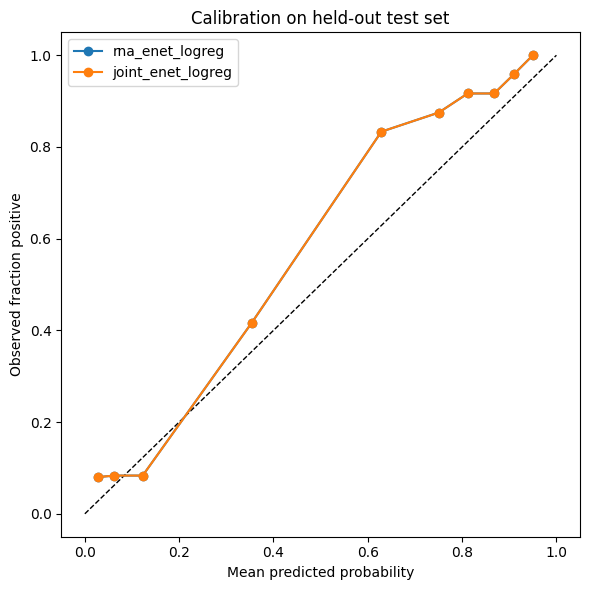

In [20]:
calibration_rows = []
plot_models = [PRIMARY_MODEL_NAME] + ([best_joint_model] if best_joint_model is not None and best_joint_model != PRIMARY_MODEL_NAME else [])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", linewidth=1)

for model_name in plot_models:
    prob = test_prob_store[model_name]
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=model_name)
    calibration_rows.append(
        {
            "model_name": model_name,
            "brier_score": brier_score_loss(y_test, prob),
        }
    )

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed fraction positive")
ax.set_title("Calibration on held-out test set")
ax.legend()
plt.tight_layout()

calibration_df = pd.DataFrame(calibration_rows)
display(calibration_df.round(4))


## 14. Task 2: multiclass TP53 mutation-type prediction with lineage-stratified splitting

This section completes the second assignment task. It reuses the existing CCLE TP53 event classes and trains true multiclass classifiers from RNA expression features. For Task 2, the split is rebuilt specifically for mutation-type prediction and is stratified by both **TP53 mutation-type class** and **CCLE lineage**. This avoids evaluating mutation-type performance on a split that was designed only for the binary TP53-mutant-vs-WT task.

In [21]:
# ============================================================
# Task 2: true multiclass TP53 mutation-type prediction in CCLE
# ============================================================
# Methodological change from the initial completed version:
#   * Task 2 gets its own train/validation/test split.
#   * The split is stratified by TP53 mutation-type label and CCLE lineage together.
#   * Hyperparameter CV also stratifies by the same label-lineage strata when feasible.
#   * Model selection is by validation macro-F1, not by test performance.

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

TASK2_LABEL_COL = "TP53_task2_label"
TASK2_TEST_SIZE = 0.15
TASK2_VAL_SIZE = 0.15

if TASK2_LABEL_COL not in sample_meta.columns:
    if "mut_type" in sample_meta.columns:
        sample_meta[TASK2_LABEL_COL] = sample_meta["mut_type"].astype(str)
    elif "TP53_event_class" in sample_meta.columns:
        sample_meta[TASK2_LABEL_COL] = sample_meta["TP53_event_class"].fillna("wild_type").astype(str)
    else:
        raise ValueError("Cannot construct CCLE Task 2 label: missing mut_type/TP53_event_class.")

# Final CCLE Task 2 classes from the EDA notebook.
task2_labels = ["wild_type", "missense_or_inframe", "lof_or_splice"]

unexpected_task2 = sorted(set(sample_meta[TASK2_LABEL_COL].dropna().astype(str)) - set(task2_labels))
if unexpected_task2:
    raise ValueError(f"Unexpected CCLE Task 2 labels: {unexpected_task2}")

if lineage_col is None or lineage_col not in sample_meta.columns:
    raise ValueError(
        "Task 2 now requires a CCLE lineage column for label-lineage stratification. "
        "Check the EDA schema and sample metadata."
    )


def make_stable_joint_strata(labels, groups, min_count=2, group_name="group"):
    """Create label+group strata, collapsing sparse group-label cells to a rare bucket.

    Stratified splitting fails if any stratum has too few samples. This helper keeps
    common label-lineage strata intact and collapses sparse cells within each label
    into a rare-lineage bucket. If that is still too sparse, it falls back to label-only
    strata and prints an explicit warning.
    """
    labels = pd.Series(labels).astype(str).reset_index(drop=True)
    groups = pd.Series(groups).astype(str).fillna("missing").replace({"nan": "missing"}).reset_index(drop=True)
    joint = labels + "__" + groups
    rare_joint = joint.value_counts().loc[lambda s: s < int(min_count)].index

    groups_collapsed = groups.copy()
    groups_collapsed.loc[joint.isin(rare_joint)] = f"RARE_{group_name.upper()}"
    joint_collapsed = labels + "__" + groups_collapsed

    if joint_collapsed.value_counts().min() < int(min_count):
        print(
            f"Warning: some label-{group_name} strata remain too small for min_count={min_count}; "
            "falling back to label-only stratification for this split/CV object."
        )
        return labels

    return joint_collapsed


def make_task2_lineage_pipeline(meta_col):
    return Pipeline(
        steps=[
            (
                "prep",
                ColumnTransformer(
                    transformers=[
                        ("lineage", make_dense_onehot_encoder(), [meta_col]),
                    ],
                    remainder="drop",
                ),
            ),
            (
                "clf",
                LogisticRegression(
                    max_iter=8000,
                    class_weight="balanced",
                    solver="lbfgs",
                    random_state=RNG,
                ),
            ),
        ]
    )


task2_counts = (
    sample_meta[TASK2_LABEL_COL]
    .value_counts()
    .reindex(task2_labels)
    .rename_axis("TP53_task2_label")
    .to_frame("n")
)

# Task 2 uses all eligible samples but creates a new split that is stratified by
# mutation-type class and lineage. This is preferable to reusing the binary Task 1 split.
y2_all = sample_meta[TASK2_LABEL_COL].astype(str)
task2_all_idx = pd.Index(sample_meta.index[y2_all.isin(task2_labels)], name=sample_meta.index.name)
task2_lineage_all = (
    sample_meta.loc[task2_all_idx, lineage_col]
    .astype(str)
    .fillna("missing")
    .replace({"nan": "missing"})
)

task2_strata_all = make_stable_joint_strata(
    labels=y2_all.loc[task2_all_idx],
    groups=task2_lineage_all,
    min_count=2,
    group_name="lineage",
)

task2_trainval_idx, task2_test_idx = train_test_split(
    task2_all_idx,
    test_size=TASK2_TEST_SIZE,
    random_state=RNG,
    shuffle=True,
    stratify=task2_strata_all,
)

task2_trainval_idx = pd.Index(task2_trainval_idx, name=sample_meta.index.name)
task2_test_idx = pd.Index(task2_test_idx, name=sample_meta.index.name)

task2_trainval_strata = make_stable_joint_strata(
    labels=y2_all.loc[task2_trainval_idx],
    groups=sample_meta.loc[task2_trainval_idx, lineage_col],
    min_count=2,
    group_name="lineage",
)

task2_val_fraction_of_trainval = TASK2_VAL_SIZE / (1.0 - TASK2_TEST_SIZE)
task2_train_idx, task2_val_idx = train_test_split(
    task2_trainval_idx,
    test_size=task2_val_fraction_of_trainval,
    random_state=RNG,
    shuffle=True,
    stratify=task2_trainval_strata,
)

task2_train_idx = pd.Index(task2_train_idx, name=sample_meta.index.name)
task2_val_idx = pd.Index(task2_val_idx, name=sample_meta.index.name)
task2_trainval_idx = task2_train_idx.union(task2_val_idx)

# Feature matrices for Task 2.
X2_train = X_joint.loc[task2_train_idx]
X2_val = X_joint.loc[task2_val_idx]
X2_test = X_joint.loc[task2_test_idx]
X2_trainval = X_joint.loc[task2_trainval_idx]

X2_meta_all = sample_meta[[lineage_col]].copy()
X2_meta_all[lineage_col] = X2_meta_all[lineage_col].astype(str).fillna("missing").replace({"nan": "missing"})
X2_meta_train = X2_meta_all.loc[task2_train_idx]
X2_meta_val = X2_meta_all.loc[task2_val_idx]
X2_meta_test = X2_meta_all.loc[task2_test_idx]
X2_meta_trainval = X2_meta_all.loc[task2_trainval_idx]

y2_train = y2_all.loc[task2_train_idx]
y2_val = y2_all.loc[task2_val_idx]
y2_test = y2_all.loc[task2_test_idx]
y2_trainval = y2_all.loc[task2_trainval_idx]

split_task2_counts = pd.concat(
    {
        "train": y2_train.value_counts().reindex(task2_labels),
        "val": y2_val.value_counts().reindex(task2_labels),
        "test": y2_test.value_counts().reindex(task2_labels),
    },
    axis=1,
).fillna(0).astype(int)

task2_lineage_split_counts = pd.concat(
    {
        "train": X2_meta_train[lineage_col].value_counts(),
        "val": X2_meta_val[lineage_col].value_counts(),
        "test": X2_meta_test[lineage_col].value_counts(),
    },
    axis=1,
).fillna(0).astype(int).sort_values("train", ascending=False)

print("CCLE Task 2 class counts:")
display(task2_counts)
print("CCLE Task 2 split counts using label-lineage stratification:")
display(split_task2_counts)
print("CCLE Task 2 lineage split counts, top 20 lineages:")
display(task2_lineage_split_counts.head(20))


def align_multiclass_proba(estimator, X, labels):
    """Return probability columns aligned to a fixed class order."""
    labels = list(labels)
    if hasattr(estimator, "predict_proba"):
        raw = estimator.predict_proba(X)
        est_classes = list(estimator.classes_)
    elif hasattr(estimator, "decision_function"):
        score = np.asarray(estimator.decision_function(X), dtype=float)
        if score.ndim == 1:
            score = np.column_stack([-score, score])
        score = score - np.nanmax(score, axis=1, keepdims=True)
        exp_score = np.exp(score)
        raw = exp_score / np.clip(exp_score.sum(axis=1, keepdims=True), 1e-12, None)
        est_classes = list(estimator.classes_)
    else:
        pred = estimator.predict(X)
        raw = np.zeros((len(pred), len(labels)), dtype=float)
        est_classes = labels
        for i, p in enumerate(pred):
            if p in labels:
                raw[i, labels.index(p)] = 1.0

    out = np.zeros((raw.shape[0], len(labels)), dtype=float)
    for j, cls in enumerate(labels):
        if cls in est_classes:
            out[:, j] = raw[:, est_classes.index(cls)]
    out = out / np.clip(out.sum(axis=1, keepdims=True), 1e-12, None)
    return out


def evaluate_multiclass(y_true, proba, labels):
    y_true = pd.Series(y_true).astype(str).to_numpy()
    labels = list(labels)
    y_pred = np.asarray(labels, dtype=object)[np.argmax(proba, axis=1)]

    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    try:
        y_bin = label_binarize(y_true, classes=labels)
        out["ovr_auroc_macro"] = roc_auc_score(y_bin, proba, average="macro", multi_class="ovr")
        out["ovr_auprc_macro"] = average_precision_score(y_bin, proba, average="macro")
    except Exception as exc:
        out["ovr_auroc_macro"] = np.nan
        out["ovr_auprc_macro"] = np.nan
        out["auc_note"] = repr(exc)

    return out, y_pred


def multiclass_report_df(y_true, y_pred, labels):
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).T.reset_index().rename(columns={"index": "class"})


class RNAMulticlassKBestFeatureBuilder(BaseEstimator, TransformerMixin):
    """Fold-safe multiclass RNA feature builder using train-fold ANOVA F scores."""

    def __init__(self, rna_cols, k=1000):
        self.rna_cols = rna_cols
        self.k = k

    def fit(self, X, y):
        X_df = self._to_frame(X)
        self.rna_cols_ = list(self.rna_cols)
        X_rna = X_df.loc[:, self.rna_cols_]
        k_eff = min(int(self.k), X_rna.shape[1])

        self.selector_ = SelectKBest(score_func=f_classif, k=k_eff)
        X_selected = self.selector_.fit_transform(X_rna, y)

        self.scaler_ = StandardScaler()
        self.scaler_.fit(X_selected)

        self.selected_genes_ = np.asarray(self.rna_cols_)[self.selector_.get_support()]
        return self

    def transform(self, X):
        X_df = self._to_frame(X)
        X_rna = X_df.loc[:, self.rna_cols_]
        X_selected = self.selector_.transform(X_rna)
        return self.scaler_.transform(X_selected)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.selected_genes_, dtype=object)

    @staticmethod
    def _to_frame(X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("RNAMulticlassKBestFeatureBuilder expects a pandas DataFrame")
        return X


def make_task2_rna_pipeline(clf, rna_cols, k=1000):
    return Pipeline(
        steps=[
            ("features", RNAMulticlassKBestFeatureBuilder(rna_cols=rna_cols, k=k)),
            ("clf", clf),
        ]
    )


task2_cv_n = min(CONFIG["cv_splits"], int(y2_train.value_counts().min()))
task2_cv_strata = make_stable_joint_strata(
    labels=y2_train,
    groups=X2_meta_train[lineage_col],
    min_count=task2_cv_n,
    group_name="lineage",
)
task2_cv = list(
    StratifiedKFold(n_splits=task2_cv_n, shuffle=True, random_state=RNG).split(
        np.zeros(len(y2_train)),
        task2_cv_strata,
    )
)

# Each registry entry declares the feature matrix it uses. Lineage-only is the
# required metadata baseline for checking whether RNA beats lineage composition.
task2_registry = [
    {
        "model_name": "task2_dummy_prior",
        "tier": "baseline",
        "feature_set": "lineage",
        "estimator": DummyClassifier(strategy="prior"),
        "param_grid": {},
    },
    {
        "model_name": "task2_lineage_only_logreg",
        "tier": "metadata_only",
        "feature_set": "lineage",
        "estimator": make_task2_lineage_pipeline(lineage_col),
        "param_grid": {"clf__C": [0.03, 0.1, 0.3, 1.0, 3.0]},
    },
    {
        "model_name": "task2_rna_multinomial_logreg",
        "tier": "mrna",
        "feature_set": "rna",
        "estimator": make_task2_rna_pipeline(
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                max_iter=8000,
                class_weight="balanced",
                random_state=RNG,
            ),
            rna_cols=rna_cols,
            k=1000,
        ),
        "param_grid": {
            "features__k": [500, 1000, 2000],
            "clf__C": [0.03, 0.1, 0.3],
            "clf__l1_ratio": [0.0, 0.5],
        },
    },
    {
        "model_name": "task2_rna_linear_svm",
        "tier": "mrna",
        "feature_set": "rna",
        "estimator": make_task2_rna_pipeline(
            SVC(
                kernel="linear",
                probability=True,
                class_weight="balanced",
                random_state=RNG,
            ),
            rna_cols=rna_cols,
            k=1000,
        ),
        "param_grid": {
            "features__k": [500, 1000],
            "clf__C": [0.03, 0.1, 0.3],
        },
    },
]

task2_feature_sets = {
    "rna": {
        "train": X2_train,
        "val": X2_val,
        "test": X2_test,
        "trainval": X2_trainval,
    },
    "lineage": {
        "train": X2_meta_train,
        "val": X2_meta_val,
        "test": X2_meta_test,
        "trainval": X2_meta_trainval,
    },
}

task2_val_rows = []
task2_test_rows = []
task2_best_estimators = {}
task2_best_params = {}

for spec in task2_registry:
    name = spec["model_name"]
    est = clone(spec["estimator"])
    grid = spec["param_grid"]
    feature_set = spec["feature_set"]
    X_fit = task2_feature_sets[feature_set]["train"]

    if len(grid) > 0:
        search = GridSearchCV(
            estimator=est,
            param_grid=grid,
            scoring="f1_macro",
            cv=task2_cv,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_fit, y2_train)
        best_est = search.best_estimator_
        best_params = search.best_params_
        best_cv = search.best_score_
    else:
        best_est = est.fit(X_fit, y2_train)
        best_params = {}
        best_cv = np.nan

    val_proba = align_multiclass_proba(best_est, task2_feature_sets[feature_set]["val"], task2_labels)
    val_metrics, _ = evaluate_multiclass(y2_val, val_proba, task2_labels)

    task2_val_rows.append(
        {
            "model_name": name,
            "tier": spec["tier"],
            "feature_set": feature_set,
            "cv_best_macro_f1": best_cv,
            "best_params": json.dumps(best_params),
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
    )

    # Refit on train + validation using the selected hyperparameters before the one-time test evaluation.
    refit_est = clone(spec["estimator"])
    if len(best_params) > 0:
        refit_est.set_params(**best_params)
    refit_est.fit(task2_feature_sets[feature_set]["trainval"], y2_trainval)

    test_proba = align_multiclass_proba(refit_est, task2_feature_sets[feature_set]["test"], task2_labels)
    test_metrics, test_pred = evaluate_multiclass(y2_test, test_proba, task2_labels)

    task2_test_rows.append(
        {
            "model_name": name,
            "tier": spec["tier"],
            "feature_set": feature_set,
            "cv_best_macro_f1": best_cv,
            "best_params": json.dumps(best_params),
            **{f"test_{k}": v for k, v in test_metrics.items()},
        }
    )

    task2_best_estimators[name] = refit_est
    task2_best_params[name] = best_params

task2_val_results = pd.DataFrame(task2_val_rows).sort_values(
    "val_macro_f1",
    ascending=False,
).reset_index(drop=True)

task2_validation_order = {name: rank for rank, name in enumerate(task2_val_results["model_name"], start=1)}
task2_test_results = pd.DataFrame(task2_test_rows)
task2_test_results["validation_rank"] = task2_test_results["model_name"].map(task2_validation_order)
task2_test_results = task2_test_results.sort_values("validation_rank").reset_index(drop=True)

display(task2_val_results.round(4))
display(task2_test_results.round(4))

best_task2_name = task2_val_results.iloc[0]["model_name"]
best_task2_feature_set = task2_val_results.iloc[0]["feature_set"]
best_task2_est = task2_best_estimators[best_task2_name]
best_task2_test_proba = align_multiclass_proba(
    best_task2_est,
    task2_feature_sets[best_task2_feature_set]["test"],
    task2_labels,
)
_, best_task2_test_pred = evaluate_multiclass(y2_test, best_task2_test_proba, task2_labels)

task2_confusion = pd.DataFrame(
    confusion_matrix(y2_test, best_task2_test_pred, labels=task2_labels),
    index=[f"true_{x}" for x in task2_labels],
    columns=[f"pred_{x}" for x in task2_labels],
)

task2_report = multiclass_report_df(y2_test, best_task2_test_pred, task2_labels)

print(f"Best CCLE Task 2 model by validation macro-F1: {best_task2_name}")
display(task2_confusion)
display(task2_report.round(4))


CCLE Task 2 class counts:


,n
TP53_task2_label,
wild_type,621
missense_or_inframe,625
lof_or_splice,362


CCLE Task 2 split counts using label-lineage stratification:


,train,val,test
TP53_task2_label,,,
wild_type,434,93,94
missense_or_inframe,435,95,95
lof_or_splice,255,54,53


CCLE Task 2 lineage split counts, top 20 lineages:


...

,model_name,tier,feature_set,cv_best_macro_f1,best_params,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,val_ovr_auroc_macro,val_ovr_auprc_macro
0,task2_rna_multinomial_logreg,mrna,rna,0.7832,"{""clf__C"": 0.03, ""clf__l1_ratio"": 0.5, ""featur...",0.8058,0.7991,0.7964,0.8069,0.9203,0.8285
1,task2_rna_linear_svm,mrna,rna,0.6979,"{""clf__C"": 0.03, ""features__k"": 500}",0.7479,0.7338,0.7345,0.7494,0.8843,0.7874
2,task2_lineage_only_logreg,metadata_only,lineage,0.4814,"{""clf__C"": 0.3}",0.5041,0.5233,0.4901,0.4951,0.7150,0.5110
3,task2_dummy_prior,baseline,lineage,NaN,{},0.3926,0.3333,0.1879,0.2213,0.5000,0.3333


,model_name,tier,feature_set,cv_best_macro_f1,best_params,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,test_ovr_auroc_macro,test_ovr_auprc_macro,validation_rank
0,task2_rna_multinomial_logreg,mrna,rna,0.7832,"{""clf__C"": 0.03, ""clf__l1_ratio"": 0.5, ""featur...",0.7851,0.7778,0.7753,0.7866,0.8981,0.8059,1
1,task2_rna_linear_svm,mrna,rna,0.6979,"{""clf__C"": 0.03, ""features__k"": 500}",0.7479,0.7268,0.7325,0.7482,0.8738,0.7623,2
2,task2_lineage_only_logreg,metadata_only,lineage,0.4814,"{""clf__C"": 0.3}",0.5041,0.5277,0.4880,0.4926,0.7192,0.5194,3
3,task2_dummy_prior,baseline,lineage,NaN,{},0.3926,0.3333,0.1879,0.2213,0.5000,0.3333,4


Best CCLE Task 2 model by validation macro-F1: task2_rna_multinomial_logreg


,pred_wild_type,pred_missense_or_inframe,pred_lof_or_splice
true_wild_type,73,12,9
true_missense_or_inframe,8,78,9
true_lof_or_splice,2,12,39


,class,precision,recall,f1-score,support
0,wild_type,0.8795,0.7766,0.8249,94.0000
1,missense_or_inframe,0.7647,0.8211,0.7919,95.0000
2,lof_or_splice,0.6842,0.7358,0.7091,53.0000
3,accuracy,0.7851,0.7851,0.7851,0.7851
4,macro avg,0.7761,0.7778,0.7753,242.0000
5,weighted avg,0.7917,0.7851,0.7866,242.0000


## 15. Final project conclusions

This completed notebook explicitly separates the two assignment tasks. **Task 1** is the original binary TP53 nonsynonymous mutation model, where the primary scientific comparison remains mRNA-only versus metadata-only versus mRNA plus metadata. **Task 2** is implemented as a true multiclass mutation-type prediction problem using the CCLE event classes `wild_type`, `missense_or_inframe`, and `lof_or_splice`.

For Task 2, the train/validation/test split is constructed specifically for the multiclass mutation-type problem and is stratified by both mutation-type label and CCLE lineage. A lineage-only baseline is included so that RNA-expression performance can be compared against lineage composition rather than interpreted in isolation.

The Task 1 results should be interpreted as evidence that RNA expression carries substantial TP53-related signal beyond simple lineage metadata, while the lineage-only and lineage-grouped analyses remain important checks against lineage confounding. The Task 2 results should be interpreted more cautiously because mutation-type prediction is harder and the `lof_or_splice` class is smaller than the WT and missense/in-frame classes.

## 16. Save outputs for reporting


In [22]:
save_df_map = {
    "ccle_mrna_first_validation_results.csv": val_results,
    "ccle_mrna_first_test_results.csv": test_results,
    "ccle_mrna_first_main_comparison.csv": main_comparison,
    "ccle_mrna_first_bootstrap_summary.csv": bootstrap_summary,
    "ccle_mrna_first_primary_coefficients.csv": primary_coef_df,
}

for fname, df in save_df_map.items():
    df.to_csv(PROC / fname, index=False)


if ccle_ablation_table is not None:
    ccle_ablation_table.to_csv(PROC / "ccle_mrna_first_ablation_table.csv", index=False)
if ccle_ablation_table_with_ensemble is not None:
    ccle_ablation_table_with_ensemble.to_csv(PROC / "ccle_mrna_first_ablation_table_with_ensemble.csv", index=False)
if isinstance(ccle_ablation_cv_results, pd.DataFrame) and len(ccle_ablation_cv_results) > 0:
    ccle_ablation_cv_results.to_csv(PROC / "ccle_mrna_first_ablation_cv_results.csv", index=False)
if ccle_final_model_comparison_with_ablations is not None:
    ccle_final_model_comparison_with_ablations.to_csv(PROC / "ccle_mrna_first_final_comparison_with_ablations.csv", index=False)

if joint_coef_df is not None:
    joint_coef_df.to_csv(PROC / "ccle_mrna_first_joint_coefficients.csv", index=False)
if per_lineage_primary is not None and len(per_lineage_primary) > 0:
    per_lineage_primary.to_csv(PROC / "ccle_mrna_first_per_lineage_primary.csv", index=False)
if grouped_cv_folds is not None:
    grouped_cv_folds.to_csv(PROC / "ccle_mrna_first_grouped_cv_folds.csv", index=False)
if grouped_cv_summary is not None:
    grouped_cv_summary.to_csv(PROC / "ccle_mrna_first_grouped_cv_summary.csv")
if outlier_sensitivity is not None:
    outlier_sensitivity.to_csv(PROC / "ccle_mrna_first_outlier_sensitivity.csv", index=False)
if label_sensitivity is not None:
    label_sensitivity.to_csv(PROC / "ccle_mrna_first_label_sensitivity.csv", index=False)
if calibration_df is not None:
    calibration_df.to_csv(PROC / "ccle_mrna_first_calibration.csv", index=False)


# Task 2 outputs are created only after the Task 2 section has run.
if "task2_counts" in globals():
    task2_counts.to_csv(PROC / "ccle_task2_class_counts.csv")
if "split_task2_counts" in globals():
    split_task2_counts.to_csv(PROC / "ccle_task2_split_class_counts.csv")
if "task2_val_results" in globals():
    task2_val_results.to_csv(PROC / "ccle_task2_validation_results.csv", index=False)
if "task2_test_results" in globals():
    task2_test_results.to_csv(PROC / "ccle_task2_test_results.csv", index=False)
if "task2_confusion" in globals():
    task2_confusion.to_csv(PROC / "ccle_task2_confusion_matrix.csv")
if "task2_report" in globals():
    task2_report.to_csv(PROC / "ccle_task2_classification_report.csv", index=False)

final_predictions = pd.DataFrame(index=X_test.index)
final_predictions["y_true"] = y_test
for model_name, prob in test_prob_store.items():
    final_predictions[f"prob__{model_name}"] = prob
save_parquet_with_id(final_predictions, "ccle_mrna_first_test_predictions.parquet")

run_summary = {
    "primary_label": primary_label,
    "primary_model_name": PRIMARY_MODEL_NAME,
    "best_metadata_model": best_meta_model,
    "best_joint_model": best_joint_model,
    "rna_gene_count": len(rna_cols),
    "recommended_meta_cols": recommended_meta_cols,
    "main_models": main_models,
    "has_ablation_table": bool(ccle_ablation_table is not None),
    "has_tp53_event_class": "TP53_event_class" in sample_meta.columns,
    "has_tp53_mut_ambiguous": "TP53_mut_ambiguous" in sample_meta.columns,
    "ambiguous_tp53_n": int(sample_meta["TP53_mut_ambiguous"].sum()) if "TP53_mut_ambiguous" in sample_meta.columns else None,
    "task2_label": TASK2_LABEL_COL if "TASK2_LABEL_COL" in globals() else None,
    "task2_classes": task2_labels if "task2_labels" in globals() else None,
    "best_task2_model": best_task2_name if "best_task2_name" in globals() else None,
}
with open(PROC / "ccle_mrna_first_run_summary.json", "w") as f:
    json.dump(run_summary, f, indent=2)

print("Saved revised mRNA-first modeling artifacts to:", PROC.resolve())


Saved revised mRNA-first modeling artifacts to: /kaggle/working/processed
